In [3]:
import numpy as np
from scipy import constants
import pandas as pd
pd.set_option('display.width', 10000) # Adjust for desired width
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None) # display full content in a column
import matplotlib.pyplot as plt
from tweezer_functions import * 
from IonChainTools import *
from scipy.optimize import fsolve
import matplotlib.colors as mcolors
import matplotlib.colorbar as mcolorbar
from scipy.optimize import fsolve
from scipy.optimize import curve_fit
from scipy.optimize import minimize
import matplotlib.ticker as ticker
import itertools
import math

#Constants in SI units
eps0 = constants.epsilon_0 
m = 39.9626*constants.atomic_mass
c = constants.c
e = constants.e
hbar = constants.hbar
pi = np.pi

# setting up parameters that we're not changing
qubit_wavelength = 729e-9
tweezer_wavelength = 532e-9
omega_tweezer = 2*pi*c/tweezer_wavelength
print(omega_tweezer)
df = pd.read_csv("S_P_only.csv",sep = ",",encoding = "UTF-8")
lambdares = np.array(df["wavelength (nm)"])*1e-9
omega_res = 2*pi*c/lambdares
linewidths = np.array(df["A_ki (s^-1)"])
lifetimes = linewidths
print(linewidths)
#test

3540698434791077.0
[1.47e+08 1.40e+08]


mess around with f_rf_a to see if I can get decent power for tweezer

In [4]:
Ns_to_sweep = np.arange(3, 71)
f_rf_r = 3e6
f_rf_a_30 = 1e6
f_rf_r_30 = f_rf_a_30*0.77*30/np.sqrt(np.log(30))
f_rf_a = 200e3
P = 100e-3
w0 = 1e-6
N_test = 50
ueq_dict = {N:ion_spacing(N, f_rf_a * 2 * pi)[0] for N in Ns_to_sweep}
ueq_dict_30  = {N_test:ion_spacing(N_test, f_rf_a_30 * 2 * pi)[0] for N_test in Ns_to_sweep}

print(ueq_dict_30[N_test][N_test//2 -1])
print(ueq_dict_30[N_test][N_test//2])
print((ueq_dict_30[N_test][N_test//2 -1] - ueq_dict_30[N_test][N_test//2])*1e6 ,"um")

-5.040176788724251e-07
5.040176788930725e-07
-1.0080353577654977 um


In [5]:
print(f_rf_r_30*1e-6, "MHz")

12.525528568733531 MHz


In [6]:
P = 0
U = potential(omega_tweezer,linewidths,omega_res,P,w0)
physical_params_to_radial_mode_vectors(30, ueq_dict_30[30], [14,15], tweezer_wavelength, linewidths, omega_res, f_rf_a_30*2.0*pi, f_rf_r_30*2.0*pi, P, w0, m, U)

[(12525528.56873351,
  array([-0.18257419, -0.18257419, -0.18257419, -0.18257419, -0.18257419,
         -0.18257419, -0.18257419, -0.18257419, -0.18257419, -0.18257419,
         -0.18257419, -0.18257419, -0.18257419, -0.18257419, -0.18257419,
         -0.18257419, -0.18257419, -0.18257419, -0.18257419, -0.18257419,
         -0.18257419, -0.18257419, -0.18257419, -0.18257419, -0.18257419,
         -0.18257419, -0.18257419, -0.18257419, -0.18257419, -0.18257419])),
 (12485546.280646022,
  array([-0.33364879, -0.29605523, -0.26546412, -0.23840598, -0.21356116,
         -0.19025052, -0.16806565, -0.14673537, -0.12606647, -0.1059135 ,
         -0.08616184, -0.06671742, -0.04750009, -0.02843909, -0.00946964,
          0.00946964,  0.02843909,  0.04750009,  0.06671742,  0.08616184,
          0.1059135 ,  0.12606647,  0.14673537,  0.16806565,  0.19025052,
          0.21356116,  0.23840598,  0.26546412,  0.29605523,  0.33364879])),
 (12427884.149184378,
  array([ 0.4268914 ,  0.29705275,  0.202

In [7]:
ueq_dict_30

{3: array([-4.79258560e-06,  8.03686927e-20,  4.79258560e-06]),
 4: array([-6.39239293e-06, -2.02155267e-06,  2.02155267e-06,  6.39239293e-06]),
 5: array([-7.75425023e-06, -3.65756109e-06, -5.32679230e-18,  3.65756109e-06,
         7.75425023e-06]),
 6: array([-8.95269530e-06, -5.05466978e-06, -1.64579254e-06,  1.64579254e-06,
         5.05466978e-06,  8.95269530e-06]),
 7: array([-1.00305600e-05, -6.28612880e-06, -3.05624026e-06, -3.43440119e-18,
         3.05624026e-06,  6.28612880e-06,  1.00305600e-05]),
 8: array([-1.10150293e-05, -7.39458263e-06, -4.30225795e-06, -1.41489075e-06,
         1.41489075e-06,  4.30225795e-06,  7.39458263e-06,  1.10150293e-05]),
 9: array([-1.19245810e-05, -8.40735007e-06, -5.42549214e-06, -2.66753932e-06,
        -4.23024251e-18,  2.66753932e-06,  5.42549214e-06,  8.40735006e-06,
         1.19245810e-05]),
 10: array([-1.27724224e-05, -9.34312758e-06, -6.45280836e-06, -3.79849817e-06,
        -1.25509111e-06,  1.25509111e-06,  3.79849817e-06,  6.45280

In [8]:
fromNs_to_sweep = np.arange(3, 41)
f_rf_r = 3e6
f_rf_a = 200e3
P = 100e-3
w0 = 1e-6
ueq_dict = {N:ion_spacing(N, f_rf_a * 2 * pi)[0] for N in Ns_to_sweep}
N_checking = [5,6,30]
tweezer_combos_full_radial_middle_only(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N_checking,
    f_rf_r,
    ueq_dict,
    P,
    w0,
    max_tweezed=2,
    qubit_lambda = 729e-9
)

,N,Tweezed ions,P_per_tweezer (W),Tweezer_freq_radial (Hz),Combined radial frequencies,Mode0_freq,Mode0_eigvec,Mode1_freq,Mode1_eigvec,Mode2_freq,Mode2_eigvec,Mode3_freq,Mode3_eigvec,Mode4_freq,Mode4_eigvec,Mode5_freq,Mode5_eigvec,Mode6_freq,Mode6_eigvec,Mode7_freq,Mode7_eigvec,Mode8_freq,Mode8_eigvec,Mode9_freq,Mode9_eigvec,Mode10_freq,Mode10_eigvec,Mode11_freq,Mode11_eigvec,Mode12_freq,Mode12_eigvec,Mode13_freq,Mode13_eigvec,Mode14_freq,Mode14_eigvec,Mode15_freq,Mode15_eigvec,Mode16_freq,Mode16_eigvec,Mode17_freq,Mode17_eigvec,Mode18_freq,Mode18_eigvec,Mode19_freq,Mode19_eigvec,Mode20_freq,Mode20_eigvec,Mode21_freq,Mode21_eigvec,Mode22_freq,Mode22_eigvec,Mode23_freq,Mode23_eigvec,Mode24_freq,Mode24_eigvec,Mode25_freq,Mode25_eigvec,Mode26_freq,Mode26_eigvec,Mode27_freq,Mode27_eigvec,Mode28_freq,Mode28_eigvec,Mode29_freq,Mode29_eigvec
0,5,"(2,)",0.10,2.006529e+06,"[18849555.92153876, 18849555.92153876, 18956052.28782825, 18849555.92153876, 18849555.92153876]",3.005657e+06,"[-0.28858753317916064, -0.4133258427250212, -0.7012545663729332, -0.4133258427256286, -0.288587533177503]",2.993326e+06,"[-0.6395330255084586, -0.30165793421586373, -3.4251719227821906e-12, 0.30165793421366915, 0.6395330255229643]",2.988450e+06,"[-0.6195469006692967, 0.024770688302822818, 0.4807245591335964, 0.024770688319715774, -0.6195469006605149]",2.972096e+06,"[0.30165793421642756, -0.6395330255064051, -1.3604974856793661e-11, 0.639533025525018, -0.30165793421310483]",2.965017e+06,"[-0.18132532523870748, 0.573191207842451, -0.5264465133201214, 0.5731912078216885, -0.18132532522565672]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,6,"(2, 3)",0.05,1.418830e+06,"[18849555.92153876, 18849555.92153876, 18902879.10316965, 18902879.10316965, 18849555.92153876, 18849555.92153876]",3.003589e+06,"[0.3107826106344066, 0.382248711211917, 0.5072475645129442, 0.5072475645129723, 0.38224871121230153, 0.3107826106331734]",2.993591e+06,"[-0.597940333975557, -0.3508594536909176, -0.13915818609203112, 0.13915818608882374, 0.3508594536891224, 0.597940333984859]",2.986572e+06,"[0.6040949110755052, -0.003474206113218652, -0.36750138544101774, -0.36750138544875494, -0.003474206131333314, 0.6040949110764763]",2.973708e+06,"[-0.36956852351835023, 0.4912237378350902, 0.34945435440742906, -0.34945435438975536, -0.49122373784938816, 0.3695685235092284]",2.960248e+06,"[0.19617213701709366, -0.5948729718797916, 0.32808937804706517, 0.32808937806062094, -0.5948729718720699, 0.19617213700632397]",2.948578e+06,"[-0.07672329129928848, 0.3682348206493441, -0.5987626019020975, 0.5987626019009508, -0.3682348206438755, 0.07672329129512558]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,30,"(14, 15)",0.05,1.418830e+06,"[18849555.92153876, 18849555.92153876, 18849555.92153876, 18849555.92153876, 18849555.92153876, 18849555.92153876, 18849555.92153876, 18849555.92153876, 18849555.92153876, 18849555.92153876, 18849555.92153876, 18849555.92153876, 18849555.92153876, 18849555.92153876, 18902879.10316965, 18902879.10316965, 18849555.92153876, 18849555.92153876, 18849555.92153876, 18849555.92153876, 18849555.92153876, 18849555.92153876, 18849555.92153876, 18849555.92153876, 18849555.92153876, 18849555.92153876, 18849555.92153876, 18849555.92153876, 18849555.92153876, 18849555.92153876]",3.000612e+06,"[0.17136696571664753, 0.1730524959458682, 0.1745363007929524, 0.17594571171859916, 0.17733184618804682, 0.17872434749509186, 0.18014496974263092, 0.1816128969998936, 0.18314780463387664, 0.18477261948022242, 0.18651736242016728, 0.18842654645311452, 0.19057787955995642, 0.19315036199891725, 0.19707265852738912, 0.197072658527389, 0.1931503619989129, 0.1905778795599449, 0.1884265464531021, 0.186517362420

/var/folders/hl/x665hsbj3yb97s38tndz24lw0000gn/T/ipykernel_58877/2430900563.py:62: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


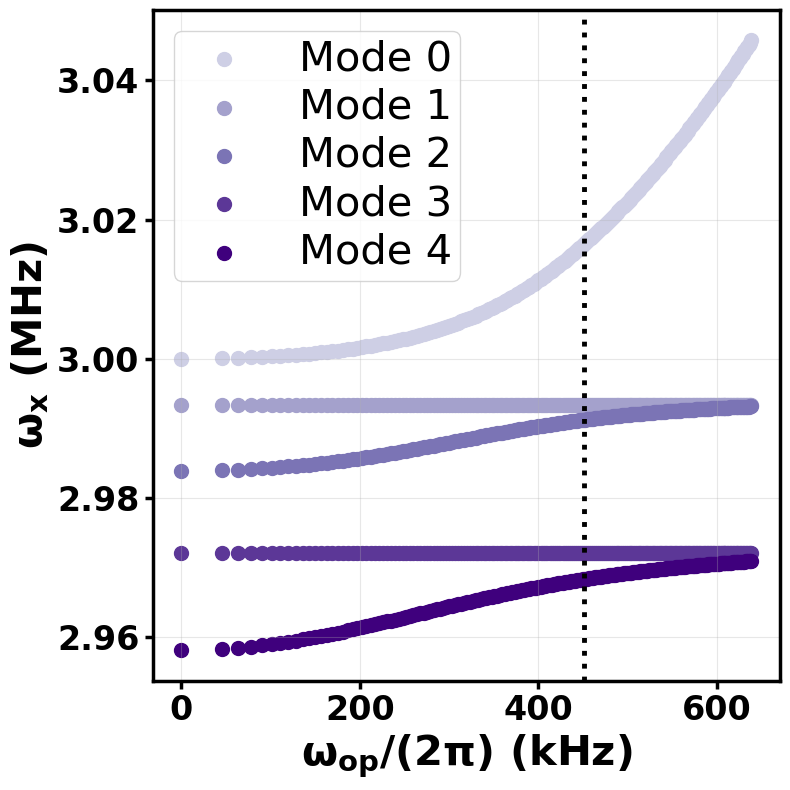

In [9]:
# Sweep over power for N=5 and plot all mode frequencies
N = 5
P_target = 0.3617034068136272
P_sweep = np.sort(np.append(np.linspace(0, 400, 200)*1e-3, P_target))  # 200 points + exact target

# Get mode frequencies and trap frequencies for each power
all_modes_N5 = []
trap_freqs_kHz = []
for P in P_sweep:
    result_df = tweezer_combos_full_radial_middle_only(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        [N],
        f_rf_r,
        ueq_dict,
        P,
        w0,
        max_tweezed=1,
        qubit_lambda=729e-9
    )
    all_modes_N5.append(result_df)
    U = potential(omega_tweezer, linewidths, omega_res, P, w0)
    omega_freq = omega_tweezer_r(U, w0, m)
    trap_freqs_kHz.append(omega_freq / (2 * pi * 1e3))

# Extract mode frequencies
mode_freqs_N5 = {i: [] for i in range(N)}
for result in all_modes_N5:
    for mode_idx in range(N):
        freq = result[f"Mode{mode_idx}_freq"].values[0]
        mode_freqs_N5[mode_idx].append(freq if not np.isnan(freq) else None)

# Reference trap frequency at P = 200 mW
U_ref = potential(omega_tweezer, linewidths, omega_res, 200e-3, w0)
trap_freq_ref_kHz = omega_tweezer_r(U_ref, w0, m) / (2 * pi * 1e3)

# Plot
px = 1 / plt.rcParams['figure.dpi']
fig, ax = plt.subplots(figsize=(800 * px, 800 * px), layout='constrained')
cmap = plt.get_cmap("Purples")
colors = [cmap(0.3 + 0.7 * i / (N - 1)) for i in range(N)]
for mode_idx in range(N):
    valid_freqs = [f for f in mode_freqs_N5[mode_idx] if f is not None]
    valid_trap_freqs = [trap_freqs_kHz[i] for i, f in enumerate(mode_freqs_N5[mode_idx]) if f is not None]
    ax.scatter(valid_trap_freqs, np.array(valid_freqs) / 1e6, marker='o', label=f'Mode {mode_idx}', s=100, color=colors[mode_idx])

ax.axvline(x=trap_freq_ref_kHz, linestyle=':', color='black', linewidth=3.5)
ax.set_xlabel(r'$\mathbf{\omega_{op}/(2\pi)}$ (kHz)', fontsize=30, fontweight='bold')
ax.set_ylabel(r'$\mathbf{\omega_{x}}$ (MHz)', fontsize=30, fontweight='bold')
ax.legend(fontsize=30, borderpad=0.2, labelspacing=0.2)
ax.grid(True, alpha=0.3)

ax.tick_params(axis='both', which='both', width=2.5, length=6, labelsize=24)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

plt.tight_layout()
plt.show()

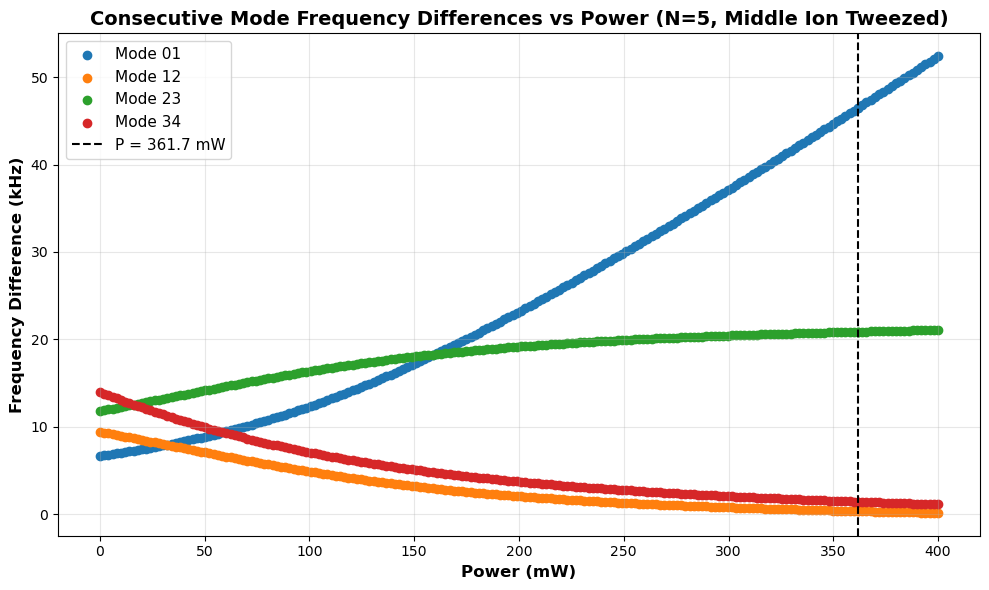

Frequency differences at P = 361.7034 mW (target: 361.7034 mW):
  Mode 0-1: 46.4672 kHz
  Mode 1-2: 0.3544 kHz
  Mode 2-3: 20.8752 kHz
  Mode 3-4: 1.4387 kHz


In [10]:
# Plot differences between consecutive mode frequencies
plt.figure(figsize=(10, 6))
for mode_idx in range(N - 1):
    freq0 = np.array(mode_freqs_N5[mode_idx], dtype=float)
    freq1 = np.array(mode_freqs_N5[mode_idx + 1], dtype=float)
    diff = freq0 - freq1
    valid_mask = ~np.isnan(freq0) & ~np.isnan(freq1)
    plt.scatter(P_sweep[valid_mask] * 1e3, diff[valid_mask] / 1e3, marker="o", label=f"Mode {mode_idx}{mode_idx+1}")

plt.axvline(x=P_target * 1e3, color="black", linestyle="--", linewidth=1.5, label=f"P = {P_target*1e3:.1f} mW")
plt.xlabel("Power (mW)", fontsize=12, fontweight="bold")
plt.ylabel("Frequency Difference (kHz)", fontsize=12, fontweight="bold")
plt.title(f"Consecutive Mode Frequency Differences vs Power (N={N}, Middle Ion Tweezed)", fontsize=14, fontweight="bold")
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print frequency differences at P_target
target_idx = np.argmin(np.abs(P_sweep - P_target))
print(f"Frequency differences at P = {P_sweep[target_idx]*1e3:.4f} mW (target: {P_target*1e3:.4f} mW):")
for mode_idx in range(N - 1):
    freq0 = np.array(mode_freqs_N5[mode_idx], dtype=float)
    freq1 = np.array(mode_freqs_N5[mode_idx + 1], dtype=float)
    diff_val = freq0[target_idx] - freq1[target_idx]
    print(f"  Mode {mode_idx}-{mode_idx+1}: {diff_val/1e3:.4f} kHz")

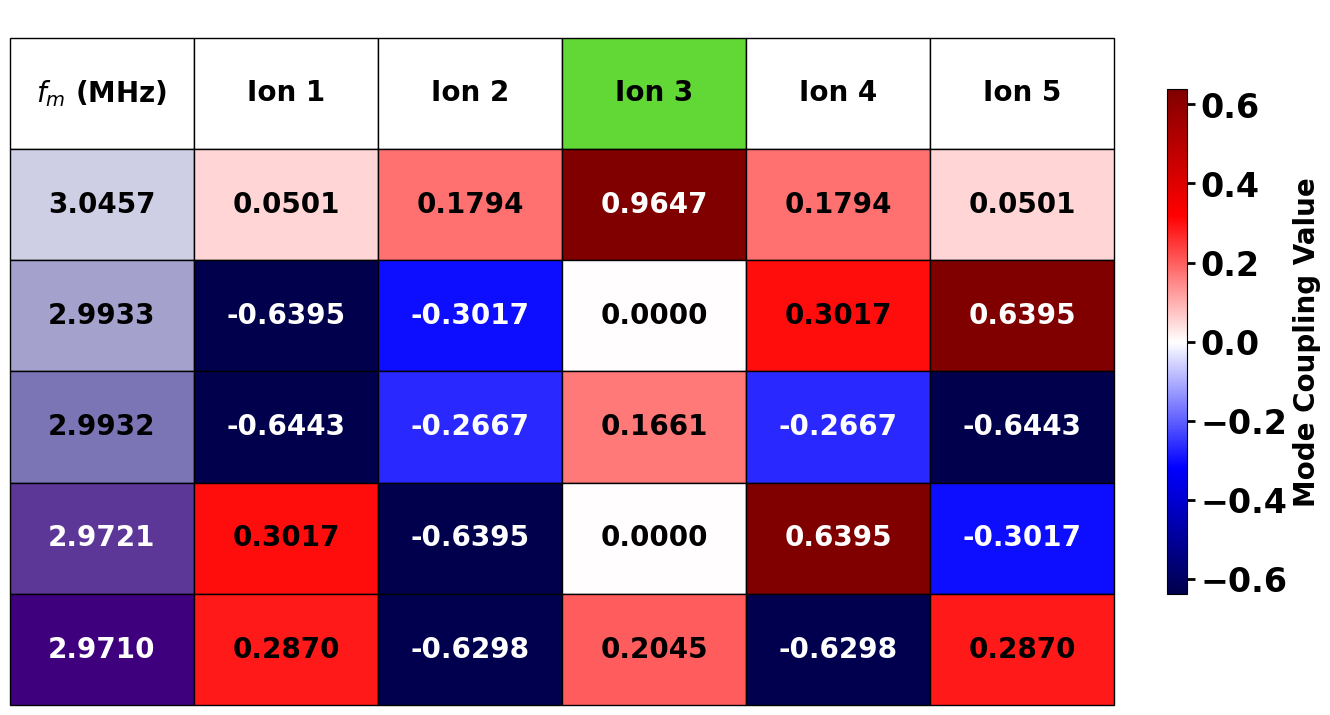

In [11]:
plot_mode_table_from_results(
    result_df, row_idx=0,
    fontsize=20,
    bold=True,
    cell_scale=(1, 1),
    col_labels=["$f_{{m}}$ (MHz)", "Ion 1", "Ion 2", "Ion 3", "Ion 4", "Ion 5"],
    row_label_fmt="{freq_mhz:.4f}",
    row_label_colors=["#cecfe5", "#a4a1cc", "#7b74b5", "#5c3797", "#3f007d"],
    value_decimals=4,
    fig_size_px=(1330, 790)
)

In [12]:
result = result_df.iloc[0]
N = int(result["N"])

freqs = []
for i in range(N):
    f = result.get(f"Mode{i}_freq", float("nan"))
    if not pd.isna(f):
        freqs.append(f)

for i in range(min(4, len(freqs) - 1)):
    diff_kHz = (freqs[i+1] - freqs[i]) / 1e3
    print(f"f{i+1} - f{i}: {diff_kHz:.3f} kHz")

f1 - f0: -52.394 kHz
f2 - f1: -0.154 kHz
f3 - f2: -21.076 kHz
f4 - f3: -1.137 kHz


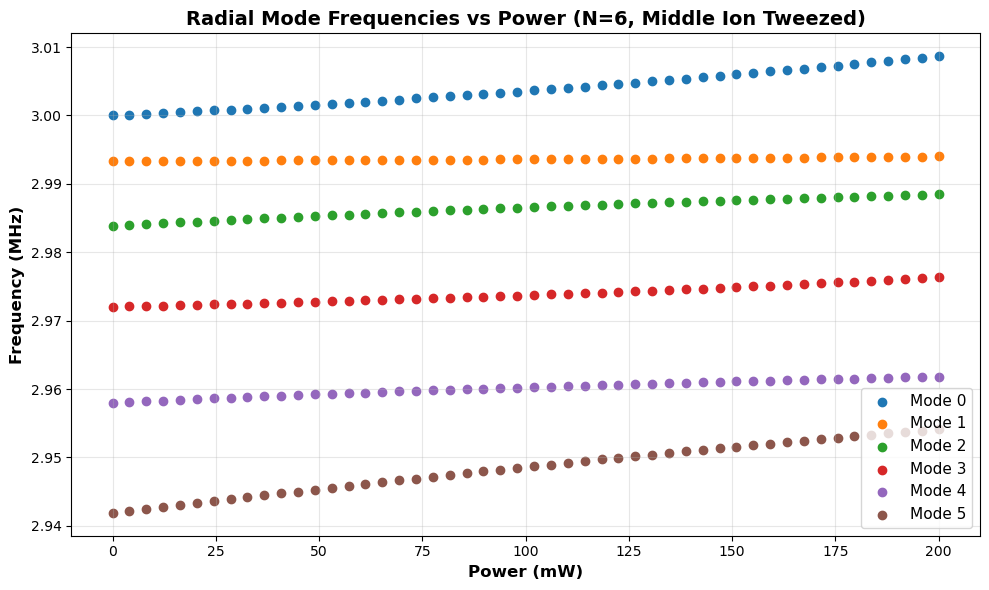

In [13]:
# Sweep over power for N=5 and plot all mode frequencies
N = 6
P_sweep = np.linspace(0, 200, 50) * 1e-3  # 0 to 200 mWW in 50 steps

# Get mode frequencies for each power
all_modes_N6 = []
for P in P_sweep:
    result_df = tweezer_combos_full_radial_middle_only(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        [N],
        f_rf_r,
        ueq_dict,
        P,
        w0,
        max_tweezed=2,
        qubit_lambda=729e-9
    )
    all_modes_N6.append(result_df)

# Extract mode frequencies
mode_freqs_N6 = {i: [] for i in range(N)}
for result in all_modes_N6:
    for mode_idx in range(N):
        freq = result[f"Mode{mode_idx}_freq"].values[0]
        mode_freqs_N6[mode_idx].append(freq if not np.isnan(freq) else None)

# Plot
plt.figure(figsize=(10, 6))
for mode_idx in range(N):
    valid_freqs = [f for f in mode_freqs_N6[mode_idx] if f is not None]
    valid_powers = [P_sweep[i] * 1e3 for i, f in enumerate(mode_freqs_N6[mode_idx]) if f is not None]
    plt.scatter(valid_powers, np.array(valid_freqs) / 1e6, marker = 'o', label=f'Mode {mode_idx}')

plt.xlabel('Power (mW)', fontsize=12, fontweight='bold')
plt.ylabel('Frequency (MHz)', fontsize=12, fontweight='bold')
#plt.ylim(3,3.2)
plt.title(f'Radial Mode Frequencies vs Power (N={N}, Middle Ion Tweezed)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
def extract_mode0_at_tweezed(df):
    results = []
    for _, row in df.iterrows():
        eigvec = row["Mode0_eigvec"]
        tweezed = row["Tweezed ions"]

        if len(tweezed) == 0:
            results.append({"values": np.array([]), "quad_sum": None})

        elif len(tweezed) == 1:
            val = eigvec[tweezed[0]]
            results.append({"values": np.array([val]), "quad_sum": None})
            #print(f"N={row['N']}, 1 tweezed ion (idx {tweezed[0]}): eigvec value = {val:.6f}")

        elif len(tweezed) == 2:
            vals = eigvec[list(tweezed)]
            quad_sum = np.sqrt(np.sum(vals**2))
            results.append({"values": vals, "quad_sum": quad_sum})
            #print(f"N={row['N']}, 2 tweezed ions (idx {tweezed[0]}, {tweezed[1]}): "
            #      f"values = {vals[0]:.6f}, {vals[1]:.6f} | quad sum = {quad_sum:.6f}")

    return results

df = tweezer_combos_full_radial_middle_only(
    omega_tweezer, linewidths, omega_res, m, mode_calc_r,
    N_list=[3], f_rf_r=3e6, ueq_dict=ueq_dict, P_opt=10, w0=1e-6)
mode0_tweezed_values = extract_mode0_at_tweezed(df)
print(mode0_tweezed_values)

[{'values': array([-0.99999009]), 'quad_sum': None}]


In [15]:
result_2 = tweezer_combos_full_radial_middle_only(
    omega_tweezer, linewidths, omega_res, m, mode_calc_r,
    N_list=[30], f_rf_r=3e6, ueq_dict=ueq_dict, P_opt=100, w0=1e-6)
middle_b_N30 = extract_mode0_at_tweezed(result_2)
print(middle_b_N30)

[{'values': array([0.70677112, 0.70677112]), 'quad_sum': 0.9995253023185945}]


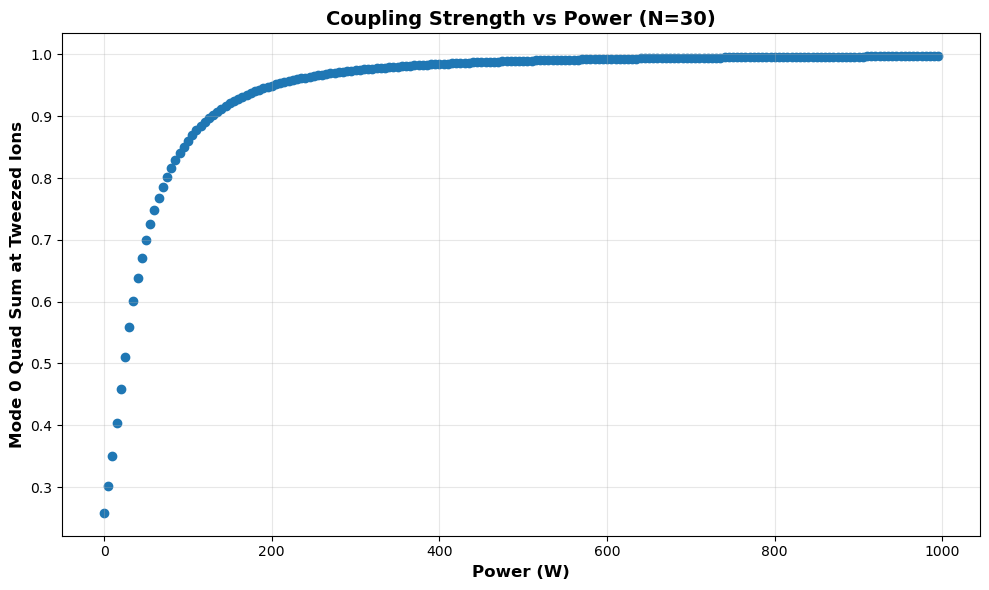

Closest to 0.90: power=130.0010 W (coupling=0.9024)


In [16]:
powers_list = np.arange(1e-3, 1000, 5)  # 0.001 to 1 W in steps of 0.05
b_30_quad_sums = []

for power in powers_list:
    results_df = tweezer_combos_full_radial_middle_only(
        omega_tweezer, linewidths, omega_res, m, mode_calc_r,
        N_list=[30], f_rf_r=f_rf_r_30, ueq_dict=ueq_dict_30, P_opt=power, w0=1e-6
    )
    extracted = extract_mode0_at_tweezed(results_df)
    
    quad_sum = extracted[0].get("quad_sum", None)
    b_30_quad_sums.append(quad_sum)

#print("Quad sum values:", b_30_quad_sums)
#print("Powers (W):", powers_list)

plt.figure(figsize=(10, 6))
plt.scatter(powers_list , b_30_quad_sums, marker='o')
plt.xlabel('Power (W)', fontsize=12, fontweight='bold')
plt.ylabel('Mode 0 Quad Sum at Tweezed Ions', fontsize=12, fontweight='bold')
plt.title('Coupling Strength vs Power (N=30)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Find power where coupling is closest to 0.9
target_coupling = 0.9
valid_pairs = [(p, b) for p, b in zip(powers_list, b_30_quad_sums) if b is not None]
if valid_pairs:
    best_power, best_coupling = min(valid_pairs, key=lambda item: abs(item[1] - target_coupling))
    print(f"Closest to {target_coupling:.2f}: power={best_power:.4f} W (coupling={best_coupling:.4f})")
else:
    print("No valid coupling values found.")

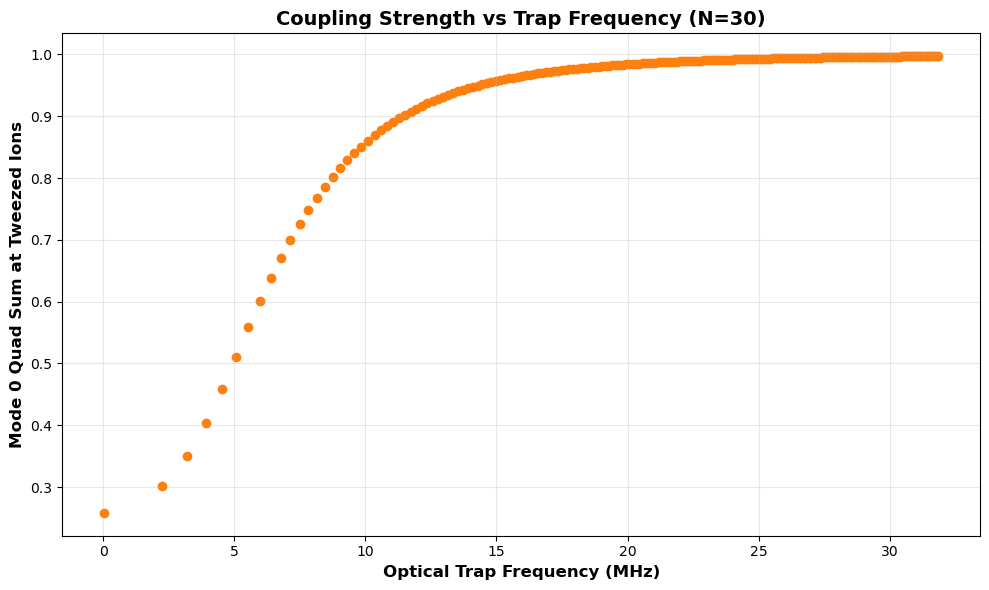

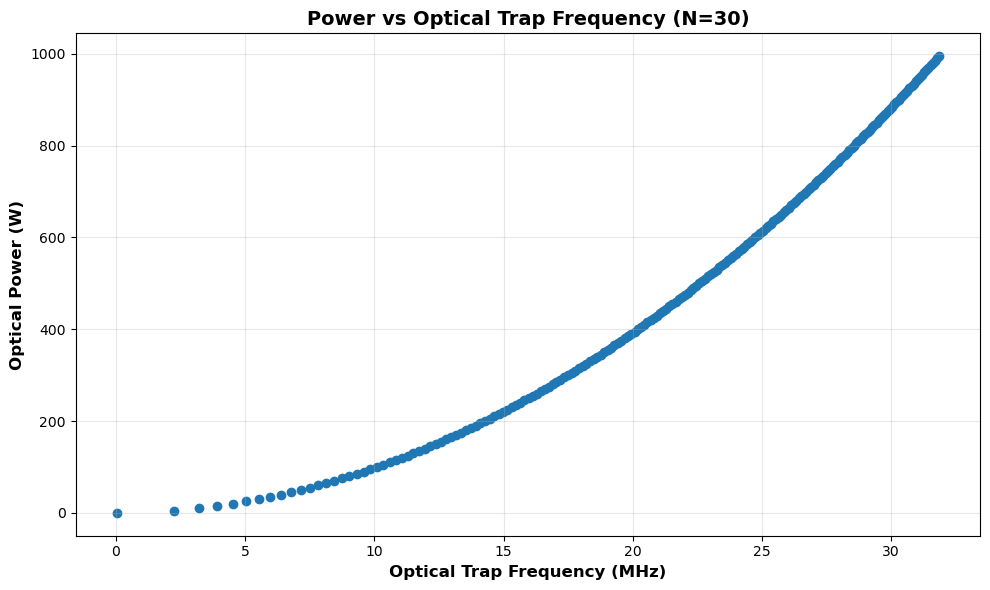

Power range: 0.001 - 995.0 W
Trap frequency range: 0.03 - 31.85 MHz
Coupling range: 0.2582 - 0.9972
Closest to 0.90: trap frequency=11.5143 MHz (coupling=0.9024)
Trap frequency at 6.0 W: 2.4737 MHz


In [17]:
# Plot coupling strength vs optical trap frequency
powers_list = np.arange(1e-3,1000, 5)  # 0.001 to 10 W in steps of 0.05
#powers_list = np.array([030,0])
b_30_quad_sums = []
trap_frequencies = []

for power in powers_list:
    # Calculate mode 0 coupling
    results_df = tweezer_combos_full_radial_middle_only(
        omega_tweezer, linewidths, omega_res, m, mode_calc_r,
        N_list=[30], f_rf_r=f_rf_r_30, ueq_dict=ueq_dict_30, P_opt=power, w0=1e-6
    )
    extracted = extract_mode0_at_tweezed(results_df)
    quad_sum = extracted[0].get("quad_sum", None)
    b_30_quad_sums.append(quad_sum)
    
    # Calculate trap frequency from potential
    U = potential(omega_tweezer, linewidths, omega_res, power, 1e-6)
    omega_freq = omega_tweezer_r(U, 1e-6, m)
    trap_frequencies.append(omega_freq/(2*pi))

# Plot: Trap Frequency vs Coupling
plt.figure(figsize=(10, 6))
plt.scatter(np.array(trap_frequencies) / 1e6, b_30_quad_sums, marker='o', color='tab:orange')
plt.xlabel('Optical Trap Frequency (MHz)', fontsize=12, fontweight='bold')
plt.ylabel('Mode 0 Quad Sum at Tweezed Ions', fontsize=12, fontweight='bold')
plt.title('Coupling Strength vs Trap Frequency (N=30)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot: Power vs Trap Frequency
plt.figure(figsize=(10, 6))
plt.scatter(np.array(trap_frequencies) / 1e6, powers_list, marker='o', color='tab:blue')
plt.xlabel('Optical Trap Frequency (MHz)', fontsize=12, fontweight='bold')
plt.ylabel('Optical Power (W)', fontsize=12, fontweight='bold')
plt.title('Power vs Optical Trap Frequency (N=30)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary
print(f"Power range: {powers_list[0]:.3f} - {powers_list[-1]:.1f} W")
print(f"Trap frequency range: {min(trap_frequencies)/1e6:.2f} - {max(trap_frequencies)/1e6:.2f} MHz")
print(f"Coupling range: {min([b for b in b_30_quad_sums if b is not None]):.4f} - {max([b for b in b_30_quad_sums if b is not None]):.4f}")

# Find trap frequency where coupling is closest to 0.9
target_coupling = 0.9
valid_pairs = [(f, b) for f, b in zip(trap_frequencies, b_30_quad_sums) if b is not None]
if valid_pairs:
    best_freq, best_coupling = min(valid_pairs, key=lambda item: abs(item[1] - target_coupling))
    print(f"Closest to {target_coupling:.2f}: trap frequency={best_freq/1e6:.4f} MHz (coupling={best_coupling:.4f})")
else:
    print("No valid coupling values found.")

# Trap frequency at 6 W
power_target = 6.0
U_target = potential(omega_tweezer, linewidths, omega_res, power_target, 1e-6)
omega_freq_target = omega_tweezer_r(U_target, 1e-6, m)
print(f"Trap frequency at {power_target:.1f} W: {omega_freq_target/1e6/(2*pi):.4f} MHz")

In [18]:
def plot_quad_sum_vs_power(N_values, powers_list, omega_tweezer, linewidths, omega_res, m, mode_calc_r, f_rf_r, ueq_dict, w0):
    """
    Plot Mode 0 quad sum vs power for multiple N values.
    For even N: extracts quad_sum (2 tweezed ions)
    For odd N: extracts absolute value of single ion b value
    
    Parameters:
    - N_values: list of ion chain sizes to plot
    - powers_list: array of power values to sweep over
    - Other parameters passed to tweezer_combos_full_radial_middle_only
    """
    plt.figure(figsize=(12, 7))
    
    for N in N_values:
        coupling_values = []
        
        for power in powers_list:
            results_df = tweezer_combos_full_radial_middle_only(
                omega_tweezer, linewidths, omega_res, m, mode_calc_r,
                N_list=[N], f_rf_r=f_rf_r, ueq_dict=ueq_dict, P_opt=power, w0=w0
            )
            extracted = extract_mode0_at_tweezed(results_df)
            
            # For even N: use quad_sum (2 tweezed ions)
            # For odd N: use absolute value of single b value (1 tweezed ion)
            if N % 2 == 0:
                value = extracted[0].get("quad_sum", None)
            else:
                b_value = extracted[0].get("values", np.array([None]))[0] if len(extracted[0].get("values", np.array([]))) > 0 else None
                value = abs(b_value) if b_value is not None else None
            
            coupling_values.append(value)
        
        plt.scatter(powers_list * 1e3, coupling_values, marker='o',   label=f'N={N}')
    
    plt.xlabel('Power (mW)', fontsize=12, fontweight='bold')
    plt.ylabel('Mode 0 Coupling at Tweezed Ions', fontsize=12, fontweight='bold')
    plt.title('Coupling Strength vs Power', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

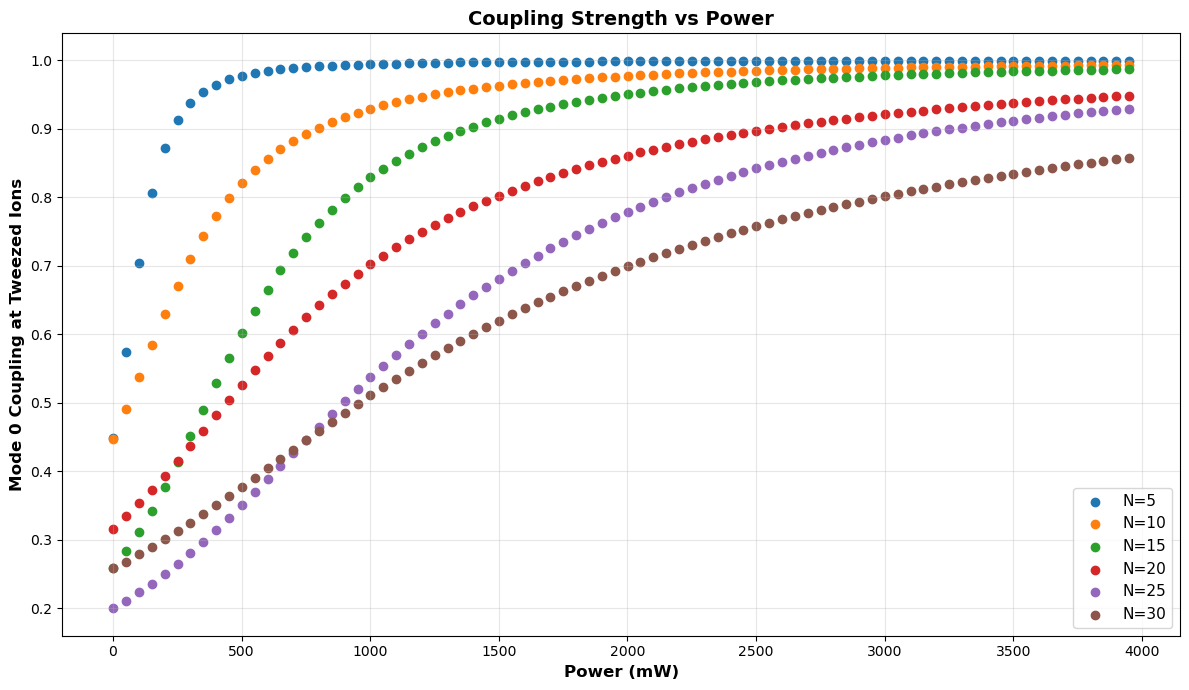

In [19]:
# Usage:
powers_list = np.arange(1e-3, 4, 0.05)  # 0.001 to 2 W in steps of 0.05
N_values = [5, 10,15,20,25, 30]  # Choose which N values to plot

plot_quad_sum_vs_power(
    N_values, 
    powers_list, 
    omega_tweezer, 
    linewidths, 
    omega_res, 
    m, 
    mode_calc_r, 
    f_rf_r=3e6, 
    ueq_dict=ueq_dict, 
    w0=1e-6
)

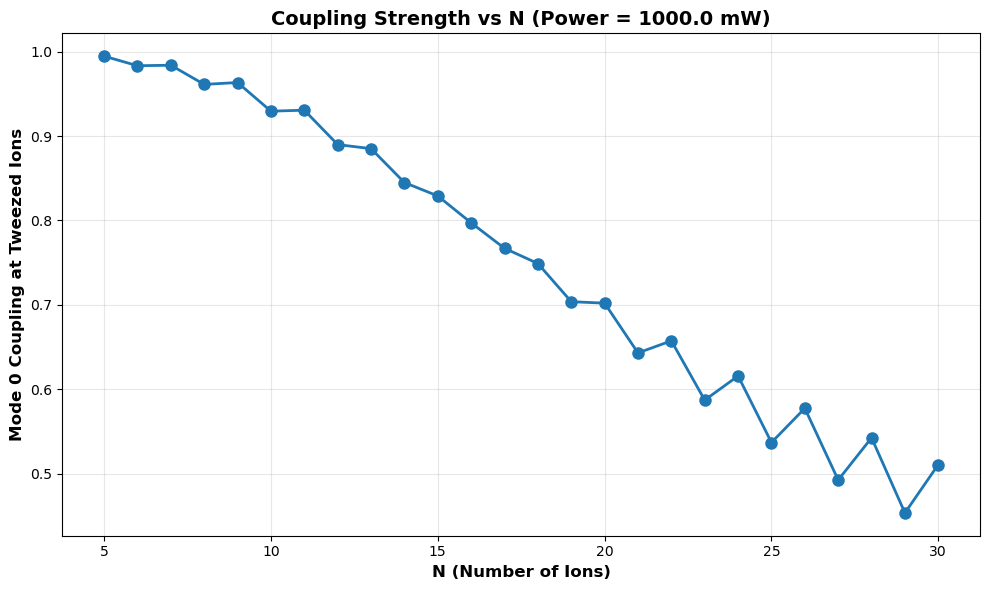

In [20]:
def plot_coupling_vs_N(N_values, power, omega_tweezer, linewidths, omega_res, m, mode_calc_r, f_rf_r, ueq_dict, w0):
    """
    Plot Mode 0 coupling vs N for a fixed power.
    For even N: extracts quad_sum (2 tweezed ions)
    For odd N: extracts absolute value of single ion b value
    
    Parameters:
    - N_values: list of ion chain sizes to sweep over
    - power: fixed power value (in Watts)
    - Other parameters passed to tweezer_combos_full_radial_middle_only
    """
    coupling_values = []
    
    for N in N_values:
        results_df = tweezer_combos_full_radial_middle_only(
            omega_tweezer, linewidths, omega_res, m, mode_calc_r,
            N_list=[N], f_rf_r=f_rf_r, ueq_dict=ueq_dict, P_opt=power, w0=w0
        )
        extracted = extract_mode0_at_tweezed(results_df)
        
        # For even N: use quad_sum (2 tweezed ions)
        # For odd N: use absolute value of single b value (1 tweezed ion)
        if N % 2 == 0:
            value = extracted[0].get("quad_sum", None)
        else:
            b_value = extracted[0].get("values", np.array([None]))[0] if len(extracted[0].get("values", np.array([]))) > 0 else None
            value = abs(b_value) if b_value is not None else None
        
        coupling_values.append(value)
    
    plt.figure(figsize=(10, 6))
    plt.plot(N_values, coupling_values, marker='o', linewidth=2, markersize=8)
    plt.xlabel('N (Number of Ions)', fontsize=12, fontweight='bold')
    plt.ylabel('Mode 0 Coupling at Tweezed Ions', fontsize=12, fontweight='bold')
    plt.title(f'Coupling Strength vs N (Power = {power*1e3:.1f} mW)', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Usage:
N_values = np.arange(5, 31, 1)  # N from 5 to 100
power = 1  # 500 mW

plot_coupling_vs_N(
    N_values,
    power,
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    f_rf_r=3e6,
    ueq_dict=ueq_dict,
    w0=1e-6
)

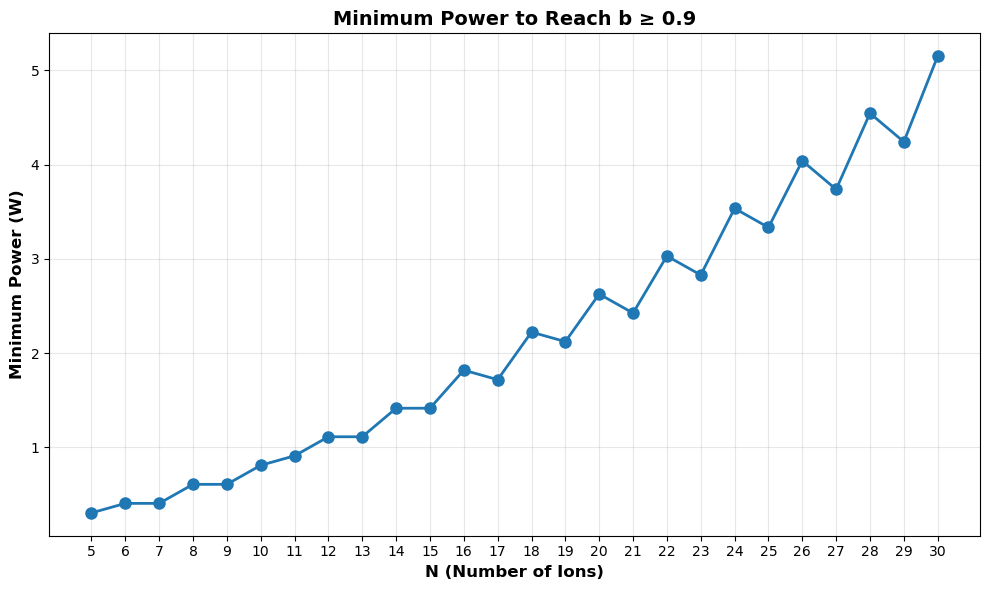

In [21]:
def plot_coupling_vs_N_at_target(N_values, target_coupling, omega_tweezer, linewidths, omega_res, m, mode_calc_r, f_rf_r, ueq_dict, w0):
    """
    Plot minimum power vs N to reach target coupling.
    For even N: uses quad_sum (2 tweezed ions)
    For odd N: uses absolute value of single ion b value
    
    Parameters:
    - N_values: list of ion chain sizes to sweep over
    - target_coupling: target coupling strength value (e.g., 0.99)
    - Other parameters passed to tweezer_combos_full_radial_middle_only
    """
    power_values = []
    N_achieved = []
    powers_for_each_N = np.linspace(0.001, 10, 100)  # Fine power sweep for finding minimum
    
    for N in N_values:
        min_power_for_target = None
        
        # Find minimum power to reach target coupling
        for power in powers_for_each_N:
            results_df = tweezer_combos_full_radial_middle_only(
                omega_tweezer, linewidths, omega_res, m, mode_calc_r,
                N_list=[N], f_rf_r=f_rf_r, ueq_dict=ueq_dict, P_opt=power, w0=w0
            )
            extracted = extract_mode0_at_tweezed(results_df)
            
            if N % 2 == 0:
                value = extracted[0].get("quad_sum", None)
            else:
                b_value = extracted[0].get("values", np.array([None]))[0] if len(extracted[0].get("values", np.array([]))) > 0 else None
                value = abs(b_value) if b_value is not None else None
            
            if value is not None and value >= target_coupling:
                min_power_for_target = power
                break
        
        # If we found a power, store it
        if min_power_for_target is not None:
            power_values.append(min_power_for_target)  # Keep in Watts
            N_achieved.append(N)
    
    plt.figure(figsize=(10, 6))
    plt.plot(N_achieved, power_values, marker='o', linewidth=2, markersize=8)
    plt.xlabel('N (Number of Ions)', fontsize=12, fontweight='bold')
    plt.ylabel('Minimum Power (W)', fontsize=12, fontweight='bold')
    plt.title(f'Minimum Power to Reach b ≥ {target_coupling}', fontsize=14, fontweight='bold')
    plt.xticks(N_achieved)  # Only show integer values on x-axis
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Usage:
N_values = np.arange(5, 31, 1)  # N from 5 to 30
target_coupling = 0.9  # Target coupling strength

plot_coupling_vs_N_at_target(
    N_values,
    target_coupling,
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    f_rf_r=3e6,
    ueq_dict=ueq_dict,
    w0=1e-6
)

In [22]:
def plot_coupling_vs_N_at_target_separate(N_values, target_coupling, omega_tweezer, linewidths, omega_res, m, mode_calc_r, f_rf_r, ueq_dict, w0):
    """
    Plot minimum power vs N to reach target coupling on separate figures for even and odd N.
    For even N: uses quad_sum (2 tweezed ions)
    For odd N: uses absolute value of single ion b value

    Parameters:
    - N_values: list of ion chain sizes to sweep over
    - target_coupling: target coupling strength value (e.g., 0.99)
    - Other parameters passed to tweezer_combos_full_radial_middle_only

    Returns:
    - dict mapping N -> minimum power (W) to reach target coupling
    """
    power_values_even = []
    N_achieved_even = []
    power_values_odd = []
    N_achieved_odd = []
    powers_for_each_N = np.linspace(0.001, 20, 500)

    for N in N_values:
        min_power_for_target = None

        # Find minimum power to reach target coupling
        for power in powers_for_each_N:
            results_df = tweezer_combos_full_radial_middle_only(
                omega_tweezer, linewidths, omega_res, m, mode_calc_r,
                N_list=[N], f_rf_r=f_rf_r, ueq_dict=ueq_dict, P_opt=power, w0=w0
            )
            extracted = extract_mode0_at_tweezed(results_df)

            if N % 2 == 0:
                value = extracted[0].get("quad_sum", None)
            else:
                b_value = extracted[0].get("values", np.array([None]))[0] if len(extracted[0].get("values", np.array([]))) > 0 else None
                value = abs(b_value) if b_value is not None else None

            if value is not None and value >= target_coupling:
                min_power_for_target = power
                break

        # Store result in appropriate list
        if min_power_for_target is not None:
            if N % 2 == 0:
                power_values_even.append(min_power_for_target)
                N_achieved_even.append(N)
            else:
                power_values_odd.append(min_power_for_target)
                N_achieved_odd.append(N)

    # Plot even N values
    if len(N_achieved_even) > 0:
        plt.figure(figsize=(10, 6))
        plt.plot(N_achieved_even, power_values_even, marker="o", markersize=9, color="#1f77b4", label="Even N", linestyle="None")
        plt.plot(N_achieved_odd, power_values_odd, marker="s", markersize=9, color="#ff7f0e", label="Odd N", linestyle="None")
        plt.xlabel("N (Number of Ions)", fontsize=12, fontweight="bold")
        plt.ylabel("Minimum Power (W)", fontsize=12, fontweight="bold")
        plt.title(f"Minimum Power to Reach b ≥ {target_coupling}", fontsize=14, fontweight="bold")
        plt.xticks(sorted(N_achieved_even + N_achieved_odd))
        plt.grid(True, alpha=0.3)
        plt.legend(fontsize=11)
        plt.tight_layout()
        plt.show()

    print(f"Even N values: {N_achieved_even}")
    print(f"Even N power values (W): {power_values_even}")
    print(f"Odd N values: {N_achieved_odd}")
    print(f"Odd N power values (W): {power_values_odd}")

    return {N: p for N, p in zip(N_achieved_even + N_achieved_odd, power_values_even + power_values_odd)}

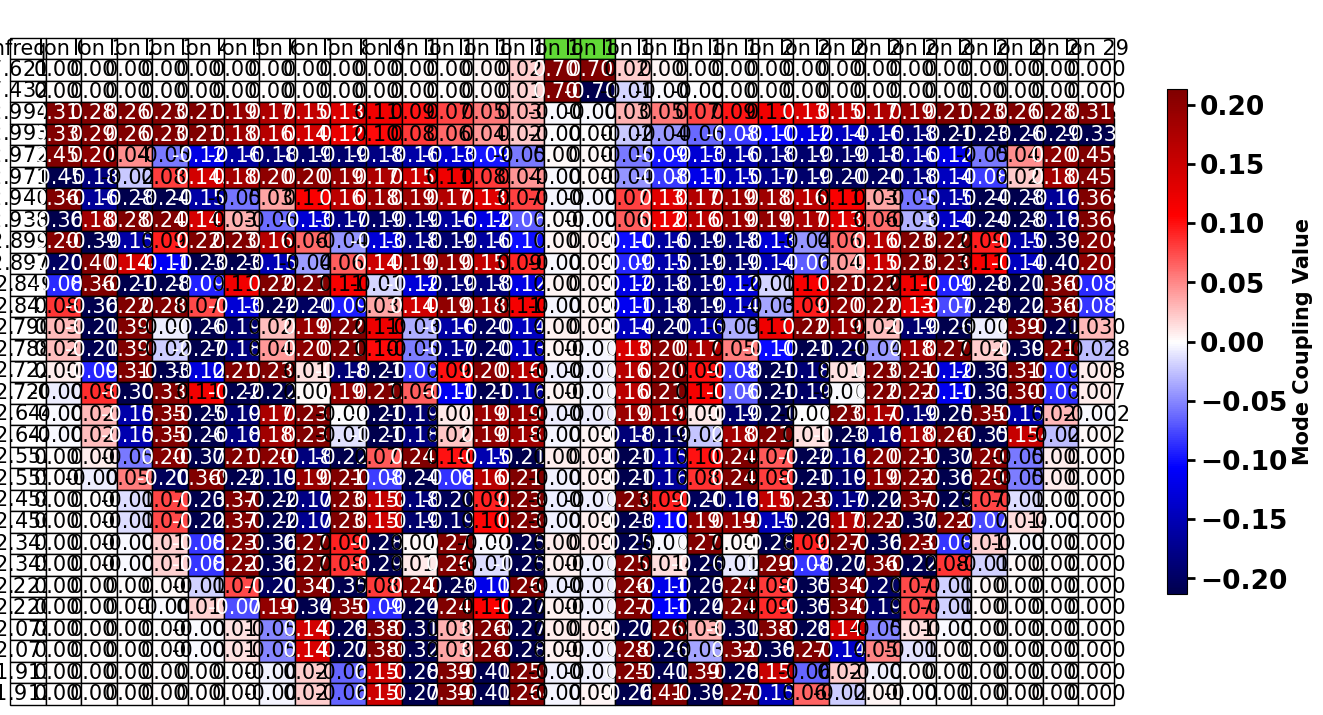

In [23]:
plot_mode_table_from_results(result_2, row_idx=0, title_suffix="(2 sections)")

In [24]:
from scipy.integrate import dblquad

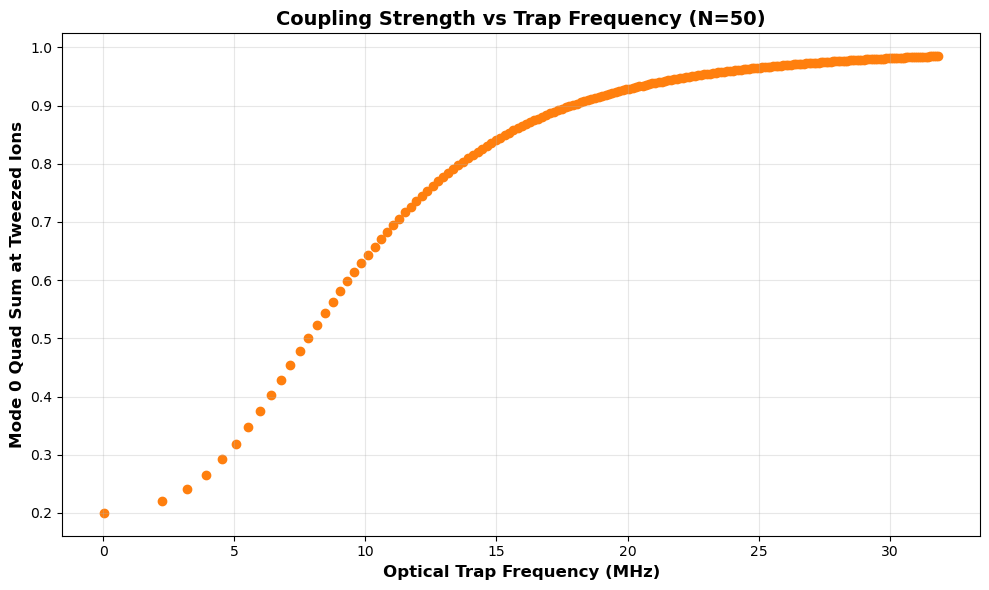

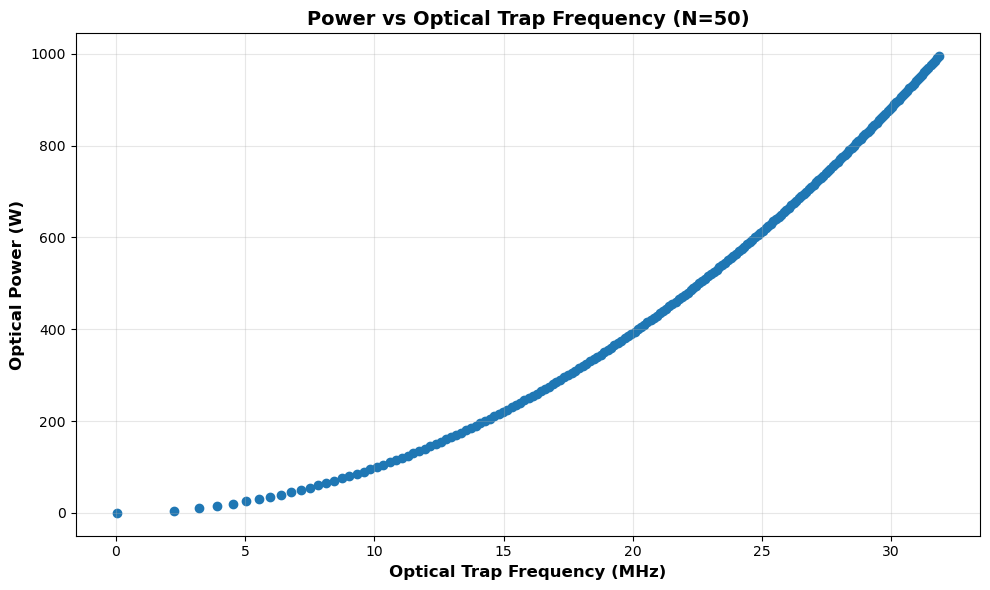

Power range: 0.001 - 995.0 W
Trap frequency range: 0.03 - 31.85 MHz
Coupling range: 0.2000 - 0.9850
Closest to 0.90: trap frequency=17.7806 MHz (coupling=0.8991)
Closest to 0.90: power=310.0010 W (coupling=0.8991)
Trap frequency at 6.0 W: 2.4737 MHz


In [25]:
# Plot coupling strength vs optical trap frequency
powers_list = np.arange(1e-3,1000, 5)  # 0.001 to 10 W in steps of 0.05
#powers_list = np.array([030,0])
b_30_quad_sums = []
trap_frequencies = []

for power in powers_list:
    # Calculate mode 0 coupling
    results_df = tweezer_combos_full_radial_middle_only(
        omega_tweezer, linewidths, omega_res, m, mode_calc_r,
        N_list=[50], f_rf_r=f_rf_a_30*0.77*50/np.sqrt(np.log(50)), ueq_dict=ueq_dict_30, P_opt=power, w0=1e-6
    )
    extracted = extract_mode0_at_tweezed(results_df)
    quad_sum = extracted[0].get("quad_sum", None)
    b_30_quad_sums.append(quad_sum)
    
    # Calculate trap frequency from potential
    U = potential(omega_tweezer, linewidths, omega_res, power, 1e-6)
    omega_freq = omega_tweezer_r(U, 1e-6, m)
    trap_frequencies.append(omega_freq/(2*pi))

# Plot: Trap Frequency vs Coupling
plt.figure(figsize=(10, 6))
plt.scatter(np.array(trap_frequencies) / 1e6, b_30_quad_sums, marker='o', color='tab:orange')
plt.xlabel('Optical Trap Frequency (MHz)', fontsize=12, fontweight='bold')
plt.ylabel('Mode 0 Quad Sum at Tweezed Ions', fontsize=12, fontweight='bold')
plt.title('Coupling Strength vs Trap Frequency (N=50)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot: Power vs Trap Frequency
plt.figure(figsize=(10, 6))
plt.scatter(np.array(trap_frequencies) / 1e6, powers_list, marker='o', color='tab:blue')
plt.xlabel('Optical Trap Frequency (MHz)', fontsize=12, fontweight='bold')
plt.ylabel('Optical Power (W)', fontsize=12, fontweight='bold')
plt.title('Power vs Optical Trap Frequency (N=50)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary
print(f"Power range: {powers_list[0]:.3f} - {powers_list[-1]:.1f} W")
print(f"Trap frequency range: {min(trap_frequencies)/1e6:.2f} - {max(trap_frequencies)/1e6:.2f} MHz")
print(f"Coupling range: {min([b for b in b_30_quad_sums if b is not None]):.4f} - {max([b for b in b_30_quad_sums if b is not None]):.4f}")

# Find trap frequency where coupling is closest to 0.9
target_coupling = 0.9
valid_pairs = [(f, b) for f, b in zip(trap_frequencies, b_30_quad_sums) if b is not None]
if valid_pairs:
    best_freq, best_coupling = min(valid_pairs, key=lambda item: abs(item[1] - target_coupling))
    print(f"Closest to {target_coupling:.2f}: trap frequency={best_freq/1e6:.4f} MHz (coupling={best_coupling:.4f})")
else:
    print("No valid coupling values found.")

# Find optical power where coupling is closest to 0.9
valid_power_pairs = [(p, b) for p, b in zip(powers_list, b_30_quad_sums) if b is not None]
if valid_power_pairs:
    best_power, best_coupling = min(valid_power_pairs, key=lambda item: abs(item[1] - target_coupling))
    print(f"Closest to {target_coupling:.2f}: power={best_power:.4f} W (coupling={best_coupling:.4f})")
else:
    print("No valid coupling values found for power search.")

# Trap frequency at 6 W
power_target = 6.0
U_target = potential(omega_tweezer, linewidths, omega_res, power_target, 1e-6)
omega_freq_target = omega_tweezer_r(U_target, 1e-6, m)
print(f"Trap frequency at {power_target:.1f} W: {omega_freq_target/1e6/(2*pi):.4f} MHz")

# TEM

In [26]:
#setting up the x_pos and y_pos and z_pos to have a zoomed out image of both TEM10 and Gaussian beams, and to find the power of both beams.
w0_TEM = 1e-6 /1.4
w0_gaussian = 1e-6
P0_gaussian = 5
P0_TEM10 = 5
n = 1
E0 = np.sqrt(2*P0_TEM10 / (c*eps0*n*w0_TEM**2*pi))
x_pos = np.arange(-4*w0_TEM,4*w0_TEM,0.001e-6)
y_pos = 0
z_pos = 0
wz = beam_propogation(w0_gaussian,z_pos,tweezer_wavelength)
wz_TEM = beam_propogation(w0_TEM,z_pos,tweezer_wavelength)
gaussian_intensity = intensity(x_pos,y_pos,P0_gaussian, wz)
gaussian_potential =  potential_position_dependent(omega_res,linewidths,omega_tweezer,gaussian_intensity)  
M_squared_Gaussian = 1
M_squared_TEM10 = 3

theta_gaussian = half_angle_beam_divergence(M_squared_Gaussian,w0_gaussian,tweezer_wavelength)
theta_TEM10 = half_angle_beam_divergence(M_squared_TEM10,w0_TEM,tweezer_wavelength)

TEM10 = intensity_TEM10(x_pos,y_pos,w0_TEM,wz_TEM,E0,n)
tem10_potential = potential_position_dependent(omega_res,linewidths,omega_tweezer,TEM10)
print("Half-Angle Beam Divergence of Gaussian beam [$\\degree$]",theta_gaussian*180/pi)
print("Half-Angle Beam Divergence of TEM10 beam [$\\degree$]",theta_TEM10*180/pi)

power_gaussian,error_gaussian = dblquad(intensity,min(x_pos),max(x_pos),min(x_pos),max(x_pos),args = (P0_gaussian,wz))
power_tem,error_tem = dblquad(intensity_TEM10,min(x_pos),max(x_pos),min(x_pos),max(x_pos),args = (w0_TEM,wz_TEM,E0,n))
#print(np.isclose(power_gaussian,power_tem,atol = 1e-9))
print("Power TEM [W]",power_tem)
print("Power Gaussian [W]", power_gaussian)

Half-Angle Beam Divergence of Gaussian beam [$\degree$] 9.702516545590267
Half-Angle Beam Divergence of TEM10 beam [$\degree$] 40.750569491479126
Power TEM [W] 4.999999999999583
Power Gaussian [W] 4.999999889648851


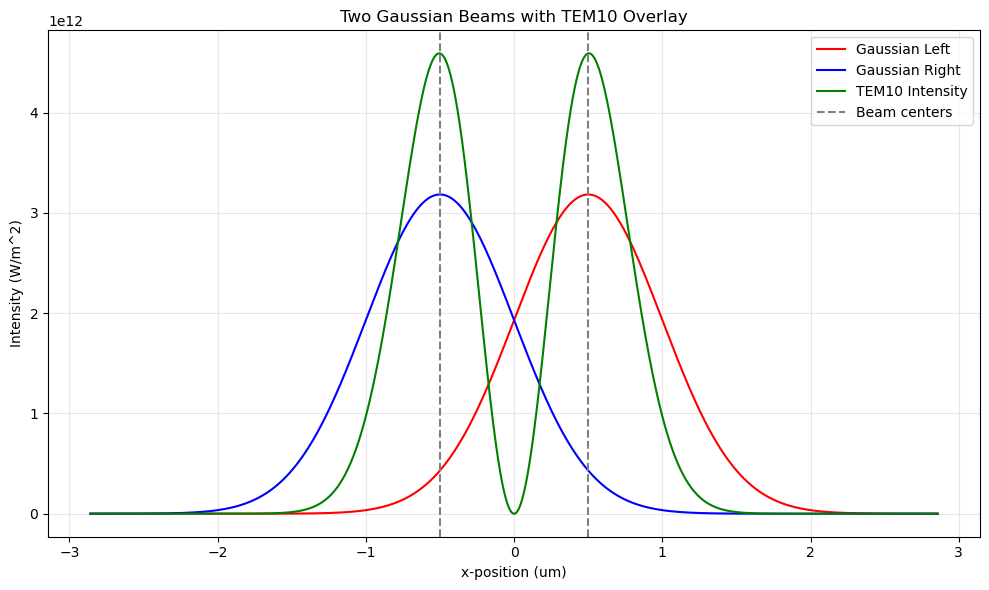

In [27]:
# Now I just want to see what two Gaussian beams look like side by side
# Set the separation between beam centers here (in microns)
beam_separation_um = 1.0
beam_separation_m = beam_separation_um * 1e-6

gaussian_left = intensity(x_pos - beam_separation_m / 2, y_pos, P0_gaussian, wz)
gaussian_right = intensity(x_pos + beam_separation_m / 2, y_pos, P0_gaussian, wz)

plt.figure(figsize=(10, 6))
plt.xlabel("x-position (um)")
plt.ylabel("Intensity (W/m^2)")
plt.plot(x_pos * 1e6, gaussian_left, 'r-', label="Gaussian Left")
plt.plot(x_pos * 1e6, gaussian_right, 'b-', label="Gaussian Right")
plt.plot(x_pos * 1e6, TEM10, 'g-', label="TEM10 Intensity")
plt.axvline(x=(beam_separation_um / 2), linestyle="dashed", color="gray", label="Beam centers")
plt.axvline(x=-(beam_separation_um / 2), linestyle="dashed", color="gray")
plt.legend(loc="best")
plt.title("Two Gaussian Beams with TEM10 Overlay")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

178.57142857142853
R-Squared value 0.9991253883241878
[-1.92623638e-23  1.48021508e-10  5.06637353e-07]
Fit Frequency [MHz] 10.630314791317138
Center of Node [nm] 506.63735290514353


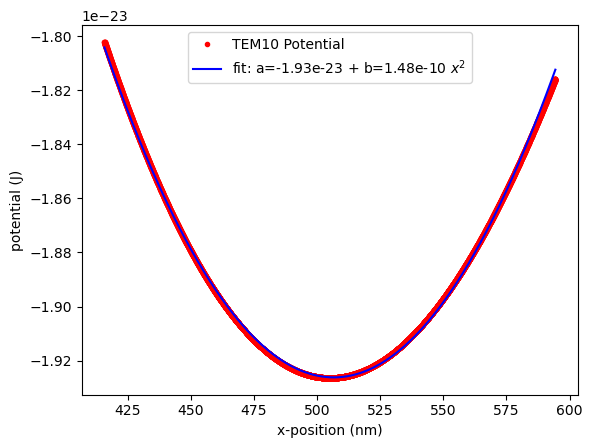

535.7142857142858
R-Squared value 0.9987293033170939
Fit Frequency [kHz] 7156.330590191611
Center of Node [nm] 5.103992855485595e-05


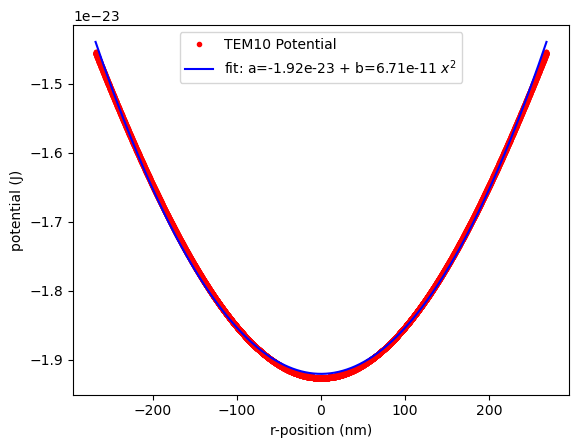

TEM10


| Column 1                    |   Column 2 |
|:----------------------------|-----------:|
| w0 [um]                     |   0.714286 |
| FWHM [um]                   |   0.571429 |
| Distance between traps [um] |   0.506637 |
| Power [W]                   |  20        |
| $\theta_x$ [deg]            |  40.7506   |
| $f_x$ [MHz]                 |  10.6303   |
| ratio of w0 to distance     |   1.40986  |

In [28]:

num_points = 10000  # Define the number of points in the range

range_width = w0_TEM*0.25  # Total range
center = w0_TEM/(np.sqrt(2))
x_pos = np.linspace(center - range_width / 2, center + range_width / 2, num_points)
print((max(x_pos)-min(x_pos))*1e9)
y_pos=0
z_pos = 0
n = 1
P0 = 20

E0 = np.sqrt(2*P0 / (c*eps0*n*w0_TEM**2*pi))
wz = beam_propogation(w0_TEM,z_pos,tweezer_wavelength)
TEM10 = intensity_TEM10(x_pos,y_pos,w0_TEM,wz,E0,n)
tem10_potential = potential_position_dependent(omega_res,linewidths,omega_tweezer,TEM10) 
def fitting_function(x,a,b,x0):
    #x0 = center
    return a + b*(x - x0)**2
xdata = x_pos
ydata = tem10_potential
popt, pcov = curve_fit(fitting_function, xdata, ydata,p0 = [-1.385153-26,6e-14,center]) 
#calculating the r-squared value of the fit
alpha_x = tuple(popt)[1]
residuals = ydata-  fitting_function(xdata, *popt)
ss_res = np.sum(residuals**2)
ss_tot = np.sum((ydata-np.mean(ydata))**2)
r_squared = 1 - (ss_res / ss_tot)
print("R-Squared value",r_squared)
#calculating the frequency from the fit 
print(popt)
omega_fit_tem_x = np.sqrt(2*popt[1]/m)
fit_center = popt[2]
print("Fit Frequency [MHz]",omega_fit_tem_x*1e-6 / (2*pi))
print("Center of Node [nm]",popt[2]*1e9)
center_left = popt[2]

plt.plot(xdata*1e9,ydata,'r.',label = "TEM10 Potential")
plt.plot(xdata*1e9,fitting_function(xdata, *popt) ,'b-',label=f'fit: a={popt[0]:.2e} + b={popt[1]:.2e} $x^{{2}}$')
plt.xlabel("x-position (nm)")
plt.ylabel("potential (J)")
#plt.title("Quadratic fit to TEM10 Potential - xslice")
plt.legend()
plt.show()


range_width = w0_TEM*0.75  # Total range
num_points = 10000  # Define the number of points in the range
center = 0
y_pos = np.linspace(center - range_width / 2, center + range_width / 2, num_points)
print((max(y_pos)-min(y_pos))*1e9)
x_pos=w0_TEM/(np.sqrt(2))
TEM10 = intensity_TEM10(x_pos,y_pos,w0_TEM,wz,E0,n)
tem10_potential = potential_position_dependent(omega_res,linewidths,omega_tweezer,TEM10) 
#plt.plot(xdata,ydata,'r.')
def fitting_function(x,a,b,x0):
    #x0 = center
    return a + b*(x - x0)**2
xdata = y_pos
ydata = tem10_potential
popt, pcov = curve_fit(fitting_function, xdata, ydata,p0 = [-1.385153-26,6e-14,center]) 
#calculating the r-squared value of the fit
alpha_x = tuple(popt)[1]
residuals = ydata-  fitting_function(xdata, *popt)
ss_res = np.sum(residuals**2)
ss_tot = np.sum((ydata-np.mean(ydata))**2)
r_squared = 1 - (ss_res / ss_tot)
print("R-Squared value",r_squared)
#calculating the frequency from the fit 
omega_fit_tem_y = np.sqrt(2*popt[1]/m)
fit_center = popt[2]
print("Fit Frequency [kHz]",omega_fit_tem_y*1e-3 / (2*pi))
print("Center of Node [nm]",popt[2]*1e9)
center_right = popt[2]

plt.plot(xdata*1e9,ydata,'r.',label = "TEM10 Potential")
plt.plot(xdata*1e9,fitting_function(xdata, *popt) ,'b-',label=f'fit: a={popt[0]:.2e} + b={popt[1]:.2e} $x^{{2}}$')
plt.xlabel("r-position (nm)")
plt.ylabel("potential (J)")
#plt.title("Quadratic fit to TEM10 Potential - yslice")
plt.legend()
plt.show()

# Create a DataFrame for the TEM10 table
from IPython.display import display, Markdown

# Function to convert DataFrame to Markdown table
def df_to_markdown(df):
    return df.to_markdown(index=False)
M_squared_TEM10 = 3
theta_TEM10 = half_angle_beam_divergence(M_squared_TEM10,w0_TEM,tweezer_wavelength)
data_tem10 = {
    'Column 1': [
        'w0 [um]',
        'FWHM [um]',
        'Distance between traps [um]',
        'Power [W]',
        r'$\theta_x$ [deg]',
        r'$f_x$ [MHz]',
        'ratio of w0 to distance'
    ],
    'Column 2': [
        w0_TEM * 1e6,
        w0_TEM * 0.8 * 1e6,
        np.abs(center_left - center_right) * 1e6,
        P0,
        theta_TEM10 * 180 / pi,
        omega_fit_tem_x * 1e-6 / (2 * pi),
        w0_TEM / np.abs(center_left - center_right)
    ]
}

df_table_tem10 = pd.DataFrame(data_tem10)
print("TEM10")
display(Markdown(df_to_markdown(df_table_tem10)))

In [29]:
def analyze_tem10_potential(P_power, w0_val, num_points=5):
    """
    Analyze TEM10 potential for a given power.
    
    Parameters:
    - P_power: optical power in Watts
    - w0_val: beam waist diameter
    - num_points: number of points in the range
    
    Returns:
    - results_dict: dictionary containing fit results for x and y positions
    - df_results: pandas DataFrame with summary of results
    """
    # X-position analysis
    range_width_x = w0_val * 0.25
    center_x = w0_val / np.sqrt(2)
    x_pos = np.linspace(center_x - range_width_x / 2, center_x + range_width_x / 2, num_points)
    
    y_pos_x = 0
    z_pos = 0
    n = 1
    
    E0 = np.sqrt(2 * P_power / (c * eps0 * n * w0_val**2 * pi))
    wz = beam_propogation(w0_val, z_pos, tweezer_wavelength)
    TEM10_x = intensity_TEM10(x_pos, y_pos_x, w0_val, wz, E0, n)
    tem10_potential_x = potential_position_dependent(omega_res, linewidths, omega_tweezer, TEM10_x)
    
    def fitting_function(x, a, b, x0):
        return a + b * (x - x0)**2
    
    # Fit x-position
    popt_x, pcov_x = curve_fit(fitting_function, x_pos, tem10_potential_x, 
                               p0=[-1.385153e-26, 6e-14, center_x])
    residuals_x = tem10_potential_x - fitting_function(x_pos, *popt_x)
    ss_res_x = np.sum(residuals_x**2)
    ss_tot_x = np.sum((tem10_potential_x - np.mean(tem10_potential_x))**2)
    r_squared_x = 1 - (ss_res_x / ss_tot_x)
    
    fit_tem_x = np.sqrt(2 * popt_x[1] / m)
    freq_x_mhz = fit_tem_x * 1e-6 / (2 * pi)
    center_left = popt_x[2]
    
    # Y-position analysis
    range_width_y = w0_val * 0.75
    center_y = 0
    y_pos = np.linspace(center_y - range_width_y / 2, center_y + range_width_y / 2, num_points)
    x_pos_y = w0_val / np.sqrt(2)
    
    TEM10_y = intensity_TEM10(x_pos_y, y_pos, w0_val, wz, E0, n)
    tem10_potential_y = potential_position_dependent(omega_res, linewidths, omega_tweezer, TEM10_y)
    
    # Fit y-position
    popt_y, pcov_y = curve_fit(fitting_function, y_pos, tem10_potential_y,
                               p0=[-1.385153e-26, 6e-14, center_y])
    residuals_y = tem10_potential_y - fitting_function(y_pos, *popt_y)
    ss_res_y = np.sum(residuals_y**2)
    ss_tot_y = np.sum((tem10_potential_y - np.mean(tem10_potential_y))**2)
    r_squared_y = 1 - (ss_res_y / ss_tot_y)
    
    fit_tem_y = np.sqrt(2 * popt_y[1] / m)
    freq_y_khz = fit_tem_y * 1e-3 / (2 * pi)
    center_right = popt_y[2]
    
    # Store detailed results
    results_dict = {
        'power_W': P_power,
        'x_position_data': {'x_pos': x_pos, 'potential': tem10_potential_x, 'fit_params': popt_x, 'r_squared': r_squared_x},
        'y_position_data': {'y_pos': y_pos, 'potential': tem10_potential_y, 'fit_params': popt_y, 'r_squared': r_squared_y},
        'E0': E0,
        'wz': wz
    }
    
    # Create summary DataFrame
    M_squared_TEM10 = 3
    theta_TEM10 = half_angle_beam_divergence(M_squared_TEM10, w0_val, tweezer_wavelength)
    
    df_results = pd.DataFrame({
        'Power (W)': [P_power],
        'w0 (um)': [w0_val * 1e6],
        'FWHM (um)': [w0_val * 0.8 * 1e6],
        'Distance between traps (um)': [np.abs(center_left - center_right) * 1e6],
        'Theta_x (deg)': [theta_TEM10 * 180 / pi],
        'freq_x (MHz)': [freq_x_mhz],
        'freq_y (kHz)': [freq_y_khz],
        'R_squared_x': [r_squared_x],
        'R_squared_y': [r_squared_y],
        'w0/distance': [w0_val / np.abs(center_left - center_right)]
    })
    
    return results_dict, df_results

# Sweep over powers and collect results
powers_to_sweep = np.arange(0.001,6,0.1)   # 0.1 to 100 mW
w0_value = 0.5e-6 * 1.4

# Dictionary to store all results
all_results = {}
all_summary_dfs = []

print("Sweeping over optical powers...")
for power in powers_to_sweep:
    print(f"  Processing power = {power*1e3:.1f} mW...")
    results_dict, df_summary = analyze_tem10_potential(power, w0_value)
    all_results[f"{power*1e3:.2f}mW"] = results_dict
    all_summary_dfs.append(df_summary)

# Combine all summary dataframes
df_power_sweep = pd.concat(all_summary_dfs, ignore_index=True)

# Save results to pickle for later access
import pickle
with open('tem10_power_sweep_results.pkl', 'wb') as f:
    pickle.dump(all_results, f)
print("Saved detailed results to: tem10_power_sweep_results.pkl")

# Save summary to CSV for easy viewing
df_power_sweep.to_csv('tem10_power_sweep_summary.csv', index=False)
print("Saved summary DataFrame to: tem10_power_sweep_summary.csv")

# Display the summary table
print("\nTEM10 Power Sweep Summary:")
display(Markdown(df_power_sweep.to_markdown(index=False)))


Sweeping over optical powers...
  Processing power = 1.0 mW...
  Processing power = 101.0 mW...
  Processing power = 201.0 mW...
  Processing power = 301.0 mW...
  Processing power = 401.0 mW...
  Processing power = 501.0 mW...
  Processing power = 601.0 mW...
  Processing power = 701.0 mW...
  Processing power = 801.0 mW...
  Processing power = 901.0 mW...
  Processing power = 1001.0 mW...
  Processing power = 1101.0 mW...
  Processing power = 1201.0 mW...
  Processing power = 1301.0 mW...
  Processing power = 1401.0 mW...
  Processing power = 1501.0 mW...
  Processing power = 1601.0 mW...
  Processing power = 1701.0 mW...
  Processing power = 1801.0 mW...
  Processing power = 1901.0 mW...
  Processing power = 2001.0 mW...
  Processing power = 2101.0 mW...
  Processing power = 2201.0 mW...
  Processing power = 2301.0 mW...
  Processing power = 2401.0 mW...
  Processing power = 2501.0 mW...
  Processing power = 2601.0 mW...
  Processing power = 2701.0 mW...
  Processing power = 2801.0 

/Users/ritika/anaconda3/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
/Users/ritika/anaconda3/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
/Users/ritika/anaconda3/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
/Users/ritika/anaconda3/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
/Users/ritika/anaconda3/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:906: 

|   Power (W) |   w0 (um) |   FWHM (um) |   Distance between traps (um) |   Theta_x (deg) |   freq_x (MHz) |   freq_y (kHz) |   R_squared_x |   R_squared_y |   w0/distance |
|------------:|----------:|------------:|------------------------------:|----------------:|---------------:|---------------:|--------------:|--------------:|--------------:|
|       0.001 |       0.7 |        0.56 |                      0.497131 |         41.5822 |      0.0780365 |         51.79  |      0.999144 |      0.999218 |       1.40808 |
|       0.101 |       0.7 |        0.56 |                      0.497131 |         41.5822 |      0.784257  |        520.483 |      0.999144 |      0.999218 |       1.40808 |
|       0.201 |       0.7 |        0.56 |                      0.497131 |         41.5822 |      1.10636   |        734.25  |      0.999144 |      0.999218 |       1.40808 |
|       0.301 |       0.7 |        0.56 |                      0.497131 |         41.5822 |      1.35388   |        898.523 |      0.999144 |      0.999218 |       1.40808 |
|       0.401 |       0.7 |        0.56 |                      0.497131 |         41.5822 |      1.56268   |       1037.09  |      0.999144 |      0.999218 |       1.40808 |
|       0.501 |       0.7 |        0.56 |                      0.497131 |         41.5822 |      1.74669   |       1159.22  |      0.999144 |      0.999218 |       1.40808 |
|       0.601 |       0.7 |        0.56 |                      0.497131 |         41.5822 |      1.91309   |       1269.65  |      0.999144 |      0.999218 |       1.40808 |
|       0.701 |       0.7 |        0.56 |                      0.497131 |         41.5822 |      2.06613   |       1371.21  |      0.999144 |      0.999218 |       1.40808 |
|       0.801 |       0.7 |        0.56 |                      0.497131 |         41.5822 |      2.20859   |       1465.76  |      0.999144 |      0.999218 |       1.40808 |
|       0.901 |       0.7 |        0.56 |                      0.497131 |         41.5822 |      2.3424    |       1554.56  |      0.999144 |      0.999218 |       1.40808 |
|       1.001 |       0.7 |        0.56 |                      0.497131 |         41.5822 |      2.46897   |       1638.56  |      0.999144 |      0.999218 |       1.40808 |
|       1.101 |       0.7 |        0.56 |                      0.497131 |         41.5822 |      2.58936   |       1718.46  |      0.999144 |      0.999218 |       1.40808 |
|       1.201 |       0.7 |        0.56 |                      0.497131 |         41.5822 |      2.70439   |       1794.81  |      0.999144 |      0.999218 |       1.40808 |
|       1.301 |       0.7 |        0.56 |                      0.497131 |         41.5822 |      2.81473   |       1868.03  |      0.999144 |      0.999218 |       1.40808 |
|       1.401 |       0.7 |        0.56 |                      0.497131 |         41.5822 |      2.9209    |       1938.5   |      0.999144 |      0.999218 |       1.40808 |
|       1.501 |       0.7 |        0.56 |                      0.497131 |         41.5822 |      3.02335   |       2006.49  |      0.999144 |      0.999218 |       1.40808 |
|       1.601 |       0.7 |        0.56 |                      0.497131 |         41.5822 |      3.12244   |       2072.25  |      0.999144 |      0.999218 |       1.40808 |
|       1.701 |       0.7 |        0.56 |                      0.497131 |         41.5822 |      3.21847   |       2135.98  |      0.999144 |      0.999218 |       1.40808 |
|       1.801 |       0.7 |        0.56 |                      0.497131 |         41.5822 |      3.31173   |       2197.87  |      0.999144 |      0.999218 |       1.40808 |
|       1.901 |       0.7 |        0.56 |                      0.497131 |         41.5822 |      3.40243   |       2258.07  |      0.999144 |      0.999218 |       1.40808 |
|       2.001 |       0.7 |        0.56 |                      0.497131 |         41.5822 |      3.49077   |       2316.7   |      0.999144 |      0.999218 |       1.40808 |
|       2.101 |       0.7 |        0.56 |                      0.497131 |         41.5822 |      3.57693   |       2373.88  |      0.999144 |      0.999218 |       1.40808 |
|       2.201 |       0.7 |        0.56 |                      0.497131 |         41.5822 |      3.66107   |       2429.72  |      0.999144 |      0.999218 |       1.40808 |
|       2.301 |       0.7 |        0.56 |                      0.497131 |         41.5822 |      3.74331   |       2484.3   |      0.999144 |      0.999218 |       1.40808 |
|       2.401 |       0.7 |        0.56 |                      0.497131 |         41.5822 |      3.82379   |       2537.71  |      0.999144 |      0.999218 |       1.40808 |
|       2.501 |       0.7 |        0.56 |                      0.497131 |         41.5822 |      3.90261   |       2590.02  |      0.999144 |      0.999218 |       1.40808 |
|       2.601 |       0.7 |        0.56 |                      0.497131 |         41.5822 |      3.97986   |       2641.29  |      0.999144 |      0.999218 |       1.40808 |
|       2.701 |       0.7 |        0.56 |                      0.497131 |         41.5822 |      4.05565   |       2691.59  |      0.999144 |      0.999218 |       1.40808 |
|       2.801 |       0.7 |        0.56 |                      0.497132 |         41.5822 |      4.13004   |       2740.96  |      0.999144 |      0.999218 |       1.40808 |
|       2.901 |       0.7 |        0.56 |                      0.497131 |         41.5822 |      4.20312   |       2789.46  |      0.999144 |      0.999218 |       1.40808 |
|       3.001 |       0.7 |        0.56 |                      0.497131 |         41.5822 |      4.27495   |       2837.13  |      0.999144 |      0.999218 |       1.40808 |
|       3.101 |       0.7 |        0.56 |                      0.497131 |         41.5822 |      4.34559   |       2884.01  |      0.999144 |      0.999218 |       1.40808 |
|       3.201 |       0.7 |        0.56 |                      0.497131 |         41.5822 |      4.4151    |       2930.14  |      0.999144 |      0.999218 |       1.40808 |
|       3.301 |       0.7 |        0.56 |                      0.497131 |         41.5822 |      4.48354   |       2975.56  |      0.999144 |      0.999218 |       1.40808 |
|       3.401 |       0.7 |        0.56 |                      0.497132 |         41.5822 |      4.55094   |       3020.29  |      0.999144 |      0.999218 |       1.40808 |
|       3.501 |       0.7 |        0.56 |                      0.497131 |         41.5822 |      4.61736   |       3064.38  |      0.999144 |      0.999218 |       1.40808 |
|       3.601 |       0.7 |        0.56 |                      0.497131 |         41.5822 |      4.68284   |       3107.83  |      0.999144 |      0.999218 |       1.40808 |
|       3.701 |       0.7 |        0.56 |                      0.497131 |         41.5822 |      4.74742   |       3150.69  |      0.999144 |      0.999218 |       1.40808 |
|       3.801 |       0.7 |        0.56 |                      0.497131 |         41.5822 |      4.81113   |       3192.97  |      0.999144 |      0.999218 |       1.40808 |
|       3.901 |       0.7 |        0.56 |                      0.497131 |         41.5822 |      4.874     |       3234.7   |      0.999144 |      0.999218 |       1.40808 |
|       4.001 |       0.7 |        0.56 |                      0.497131 |         41.5822 |      4.93608   |       3275.9   |      0.999144 |      0.999218 |       1.40808 |
|       4.101 |       0.7 |        0.56 |                      0.497131 |         41.5822 |      4.99739   |       3316.58  |      0.999144 |      0.999218 |       1.40808 |
|       4.201 |       0.7 |        0.56 |                      0.497131 |         41.5822 |      5.05795   |       3356.78  |      0.999144 |      0.999218 |       1.40808 |
|       4.301 |       0.7 |        0.56 |                      0.497131 |         41.5822 |      5.11779   |       3396.49  |      0.999144 |      0.999218 |       1.40808 |
|       4.401 |       0.7 |        0.56 |                      0.497131 |         41.5822 |      5.17695   |       3435.75  |      0.999144 |      0.999218 |       1.40808 |
|       4.501 |       0.7 |        0.56 |                      0.497131 |         41.5822 |      5.23543   |       3474.57  |      0.999144 |      0.999218 |       1.40808 |
|       4.601 |       0.7 |        0.56 |                      0.497131 |         41.5822 |      5.29327   |       3512.95  |      0.999144 |      0.999218 |       1.40808 |
|       4.701 |       0.7 |        0.56 |                      0.497131 |         41.5822 |      5.35048   |       3550.92  |      0.999144 |      0.999218 |       1.40808 |
|       4.801 |       0.7 |        0.56 |                      0.497131 |         41.5822 |      5.40709   |       3588.49  |      0.999144 |      0.999218 |       1.40808 |
|       4.901 |       0.7 |        0.56 |                      0.497131 |         41.5822 |      5.46311   |       3625.67  |      0.999144 |      0.999218 |       1.40808 |
|       5.001 |       0.7 |        0.56 |                      0.497131 |         41.5822 |      5.51857   |       3662.47  |      0.999144 |      0.999218 |       1.40808 |
|       5.101 |       0.7 |        0.56 |                      0.497131 |         41.5822 |      5.57347   |       3698.91  |      0.999144 |      0.999218 |       1.40808 |
|       5.201 |       0.7 |        0.56 |                      0.497131 |         41.5822 |      5.62784   |       3734.99  |      0.999144 |      0.999218 |       1.40808 |
|       5.301 |       0.7 |        0.56 |                      0.497131 |         41.5822 |      5.68168   |       3770.72  |      0.999144 |      0.999218 |       1.40808 |
|       5.401 |       0.7 |        0.56 |                      0.497131 |         41.5822 |      5.73502   |       3806.12  |      0.999144 |      0.999218 |       1.40808 |
|       5.501 |       0.7 |        0.56 |                      0.497131 |         41.5822 |      5.78787   |       3841.2   |      0.999144 |      0.999218 |       1.40808 |
|       5.601 |       0.7 |        0.56 |                      0.497131 |         41.5822 |      5.84024   |       3875.96  |      0.999144 |      0.999218 |       1.40808 |
|       5.701 |       0.7 |        0.56 |                      0.497131 |         41.5822 |      5.89215   |       3910.4   |      0.999144 |      0.999218 |       1.40808 |
|       5.801 |       0.7 |        0.56 |                      0.497131 |         41.5822 |      5.9436    |       3944.55  |      0.999144 |      0.999218 |       1.40808 |
|       5.901 |       0.7 |        0.56 |                      0.497131 |         41.5822 |      5.99461   |       3978.4   |      0.999144 |      0.999218 |       1.40808 |

In [30]:
# Helper functions to access and work with saved results
def load_tem10_results():
    """Load the power sweep results from pickle file."""
    import pickle
    with open('tem10_power_sweep_results.pkl', 'rb') as f:
        results = pickle.load(f)
    return results

def load_tem10_summary():
    """Load the summary DataFrame from CSV file."""
    return pd.read_csv('tem10_power_sweep_summary.csv')

def get_specific_power_analysis(power_mw, results_dict=None):
    """
    Extract and display analysis for a specific power.
    
    Parameters:
    - power_mw: power in mW
    - results_dict: the all_results dictionary (optional, loads from file if not provided)
    """
    if results_dict is None:
        results_dict = load_tem10_results()
    
    key = f"{power_mw:.2f}mW"
    if key in results_dict:
        return results_dict[key]
    else:
        print(f"Available powers: {list(results_dict.keys())}")
        return None

# Example: Access summary data
print("Loaded summary DataFrame:")
summary_df = load_tem10_summary()
print(summary_df)



Loaded summary DataFrame:
    Power (W)  w0 (um)  FWHM (um)  Distance between traps (um)  Theta_x (deg)  freq_x (MHz)  freq_y (kHz)  R_squared_x  R_squared_y  w0/distance
0       0.001      0.7       0.56                     0.497131      41.582214      0.078037     51.790005     0.999144     0.999218     1.408079
1       0.101      0.7       0.56                     0.497131      41.582214      0.784257    520.483111     0.999144     0.999218     1.408079
2       0.201      0.7       0.56                     0.497131      41.582214      1.106359    734.250048     0.999144     0.999218     1.408079
3       0.301      0.7       0.56                     0.497131      41.582214      1.353883    898.523008     0.999144     0.999218     1.408079
4       0.401      0.7       0.56                     0.497131      41.582214      1.562680   1037.094046     0.999144     0.999218     1.408079
5       0.501      0.7       0.56                     0.497131      41.582214      1.746694   1159.21720

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


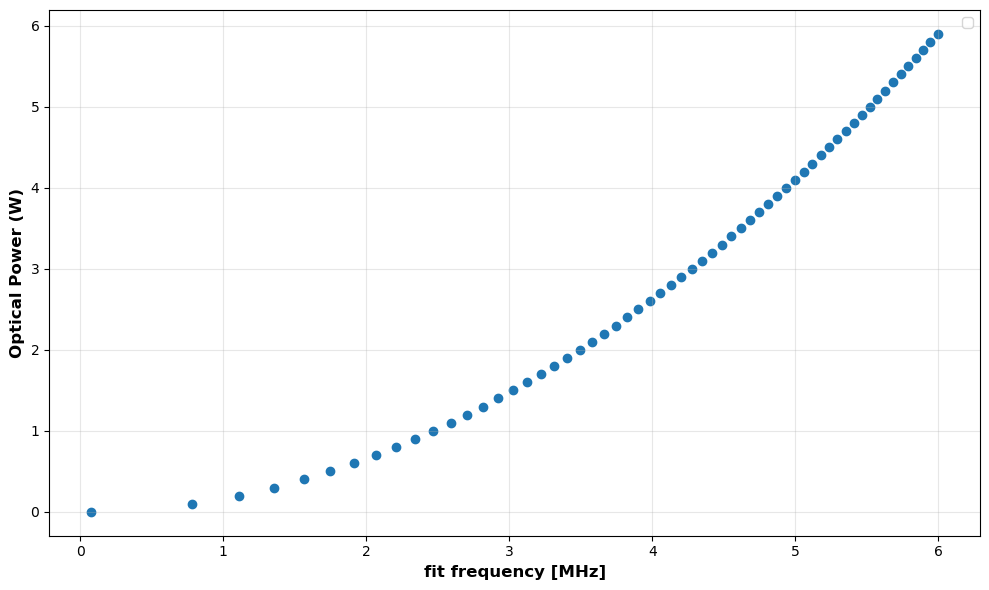

In [31]:
plt.figure(figsize=(10, 6))
plt.scatter(df_power_sweep["freq_x (MHz)"], df_power_sweep["Power (W)"], marker='o')
#plt.axvline(x=2.28, color='gray', linestyle='--', linewidth=1.5, label='x = 2.28 MHz')
plt.xlabel(r'fit frequency [MHz]', fontsize=12, fontweight='bold')
plt.ylabel('Optical Power (W)', fontsize=12, fontweight='bold')

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [32]:
# Sweep over power values at fixed w0
w0_fixed_m = w0_TEM  # Set fixed w0 here (m)
power_values_w = np.linspace(0.1, 30.0, 20)  # 20 power values in Watts

# Dictionary to store all results
all_results = {}
all_summary_dfs = []

print("Sweeping over power values...")
for power_w in power_values_w:
    print(f"  Processing power = {power_w:.3f} W...")
    results_dict, df_summary = analyze_tem10_potential(power_w, w0_fixed_m)
    all_results[f"{power_w:.3f}W"] = results_dict
    all_summary_dfs.append(df_summary)

# Combine all summary dataframes
df_power_sweep = pd.concat(all_summary_dfs, ignore_index=True)

# Save results to pickle for later access
import pickle
with open('tem10_power_sweep_results.pkl', 'wb') as f:
    pickle.dump(all_results, f)
print("Saved detailed results to: tem10_power_sweep_results.pkl")

# Save summary to CSV for easy viewing
df_power_sweep.to_csv('tem10_power_sweep_summary.csv', index=False)
print("Saved summary DataFrame to: tem10_power_sweep_summary.csv")

# Display the summary table
print("\nTEM10 power sweep summary:")
display(Markdown(df_power_sweep.to_markdown(index=False)))

Sweeping over power values...
  Processing power = 0.100 W...
  Processing power = 1.674 W...
  Processing power = 3.247 W...
  Processing power = 4.821 W...
  Processing power = 6.395 W...
  Processing power = 7.968 W...
  Processing power = 9.542 W...
  Processing power = 11.116 W...
  Processing power = 12.689 W...
  Processing power = 14.263 W...
  Processing power = 15.837 W...
  Processing power = 17.411 W...
  Processing power = 18.984 W...
  Processing power = 20.558 W...
  Processing power = 22.132 W...
  Processing power = 23.705 W...
  Processing power = 25.279 W...
  Processing power = 26.853 W...
  Processing power = 28.426 W...
  Processing power = 30.000 W...
Saved detailed results to: tem10_power_sweep_results.pkl
Saved summary DataFrame to: tem10_power_sweep_summary.csv

TEM10 power sweep summary:


/Users/ritika/anaconda3/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
/Users/ritika/anaconda3/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
/Users/ritika/anaconda3/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
/Users/ritika/anaconda3/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
/Users/ritika/anaconda3/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:906: 

|   Power (W) |   w0 (um) |   FWHM (um) |   Distance between traps (um) |   Theta_x (deg) |   freq_x (MHz) |   freq_y (kHz) |   R_squared_x |   R_squared_y |   w0/distance |
|------------:|----------:|------------:|------------------------------:|----------------:|---------------:|---------------:|--------------:|--------------:|--------------:|
|     0.1     |  0.714286 |    0.571429 |                      0.507277 |         40.7506 |       0.749463 |        497.391 |      0.999144 |      0.999218 |       1.40808 |
|     1.67368 |  0.714286 |    0.571429 |                      0.507277 |         40.7506 |       3.0661   |       2034.86  |      0.999144 |      0.999218 |       1.40808 |
|     3.24737 |  0.714286 |    0.571429 |                      0.507277 |         40.7506 |       4.27087  |       2834.42  |      0.999144 |      0.999218 |       1.40808 |
|     4.82105 |  0.714286 |    0.571429 |                      0.507277 |         40.7506 |       5.20381  |       3453.58  |      0.999144 |      0.999218 |       1.40808 |
|     6.39474 |  0.714286 |    0.571429 |                      0.507277 |         40.7506 |       5.99324  |       3977.49  |      0.999144 |      0.999218 |       1.40808 |
|     7.96842 |  0.714286 |    0.571429 |                      0.507277 |         40.7506 |       6.69016  |       4440.01  |      0.999144 |      0.999218 |       1.40808 |
|     9.54211 |  0.714286 |    0.571429 |                      0.507277 |         40.7506 |       7.32103  |       4858.7   |      0.999144 |      0.999218 |       1.40808 |
|    11.1158  |  0.714286 |    0.571429 |                      0.507277 |         40.7506 |       7.9017   |       5244.07  |      0.999144 |      0.999218 |       1.40808 |
|    12.6895  |  0.714286 |    0.571429 |                      0.507277 |         40.7506 |       8.44252  |       5602.99  |      0.999144 |      0.999218 |       1.40808 |
|    14.2632  |  0.714286 |    0.571429 |                      0.507277 |         40.7506 |       8.95072  |       5940.27  |      0.999144 |      0.999218 |       1.40808 |
|    15.8368  |  0.714286 |    0.571429 |                      0.507277 |         40.7506 |       9.43158  |       6259.4   |      0.999144 |      0.999218 |       1.40808 |
|    17.4105  |  0.714286 |    0.571429 |                      0.507277 |         40.7506 |       9.88908  |       6563.02  |      0.999144 |      0.999218 |       1.40808 |
|    18.9842  |  0.714286 |    0.571429 |                      0.507277 |         40.7506 |      10.3263   |       6853.22  |      0.999144 |      0.999218 |       1.40808 |
|    20.5579  |  0.714286 |    0.571429 |                      0.507277 |         40.7506 |      10.7458   |       7131.61  |      0.999144 |      0.999218 |       1.40808 |
|    22.1316  |  0.714286 |    0.571429 |                      0.507277 |         40.7506 |      11.1495   |       7399.53  |      0.999144 |      0.999218 |       1.40808 |
|    23.7053  |  0.714286 |    0.571429 |                      0.507277 |         40.7506 |      11.5391   |       7658.09  |      0.999144 |      0.999218 |       1.40808 |
|    25.2789  |  0.714286 |    0.571429 |                      0.507277 |         40.7506 |      11.916    |       7908.2   |      0.999144 |      0.999218 |       1.40808 |
|    26.8526  |  0.714286 |    0.571429 |                      0.507277 |         40.7506 |      12.2813   |       8150.64  |      0.999144 |      0.999218 |       1.40808 |
|    28.4263  |  0.714286 |    0.571429 |                      0.507277 |         40.7506 |      12.636    |       8386.07  |      0.999144 |      0.999218 |       1.40808 |
|    30       |  0.714286 |    0.571429 |                      0.507277 |         40.7506 |      12.9811   |       8615.07  |      0.999144 |      0.999218 |       1.40808 |

Closest row to 2.4737 MHz:


,Power (W),w0 (um),FWHM (um),Distance between traps (um),Theta_x (deg),freq_x (MHz),freq_y (kHz),R_squared_x,R_squared_y,w0/distance
1,1.673684,0.714286,0.571429,0.507277,40.750569,3.066104,2034.86155,0.999144,0.999218,1.408079


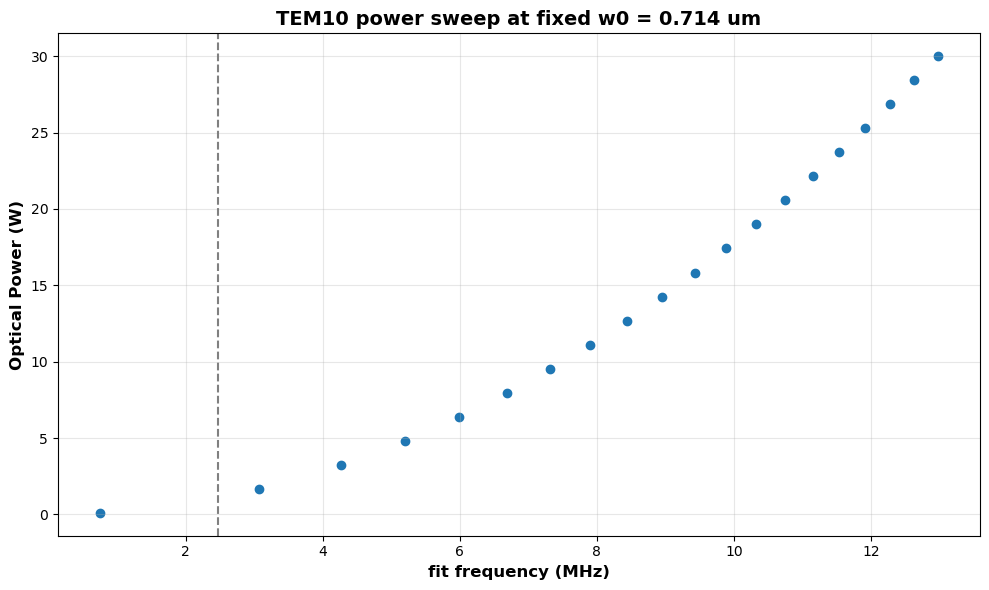

In [33]:
target_freq_mhz = 2.4737 
closest_idx = (df_power_sweep["freq_x (MHz)"] - target_freq_mhz).abs().idxmin()
closest_row = df_power_sweep.loc[closest_idx]
print("Closest row to 2.4737 MHz:")
display(closest_row.to_frame().T)

plt.figure(figsize=(10, 6))
plt.scatter(df_power_sweep["freq_x (MHz)"], df_power_sweep["Power (W)"], marker='o')
plt.xlabel('fit frequency (MHz)', fontsize=12, fontweight='bold')
plt.ylabel('Optical Power (W)', fontsize=12, fontweight='bold')
plt.title(f'TEM10 power sweep at fixed w0 = {w0_fixed_m*1e6:.3f} um', fontsize=14, fontweight='bold')
plt.axvline(x=target_freq_mhz, color='gray', linestyle='--', linewidth=1.5, label='x = 2.4737 MHz')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# how far detuned can we be and still drive full population transfer?

Omega_0 = 50 kHz (from a Ken Brown paper on sideband cooling with Ca ions)

P_g(t) = 1/2*(1+ Sum(P_n* cos(Omega_n,n+1*t)))

Omega_n,n+1 = Omega_0 * sqrt(n+1)*eta

Omega_0' = sqrt(Omega_0^2 + Delta^2)

Delta = detuning 

In [34]:
Omega_0 = 100e3 * 2 * pi  # 100 kHz in rad/s

det_min = df_mode_diffs["freq_diff_kHz"].min()
det_max = df_mode_diffs["freq_diff_kHz"].max()
detunings_kHz = np.linspace(det_min, det_max, 5)
time = np.linspace(0, 100e-6, 1000)  # Time from 0 to 100 microseconds

plt.figure(figsize=(10, 6))
for det_kHz in detunings_kHz:
    delta = det_kHz * 1e3 * 2 * pi  # convert kHz to rad/s
    Rabi_freq = np.sqrt(Omega_0**2 + delta**2)
    coeff = (Omega_0 / Rabi_freq)**2
    print(coeff)
    P = 1 - coeff * np.sin(Rabi_freq * time / 2)**2
    plt.plot(time * 1e6, P, label=f"{det_kHz:.3f} kHz detuning ({Rabi_freq/(2*pi*1e3):.1f} kHz Rabi)")

plt.xlabel("Time (\u00b5s)")
plt.ylabel("Population")
plt.ylim(0.9, 1.005)
#plt.xlim(0,10)
plt.title("Degenerate Modes \u2014 Rabi Oscillations at Various Detunings")
plt.legend()
plt.tight_layout()
plt.show()


NameError: name 'df_mode_diffs' is not defined

so what is the effect of not driving a full population transfer on cooling? 


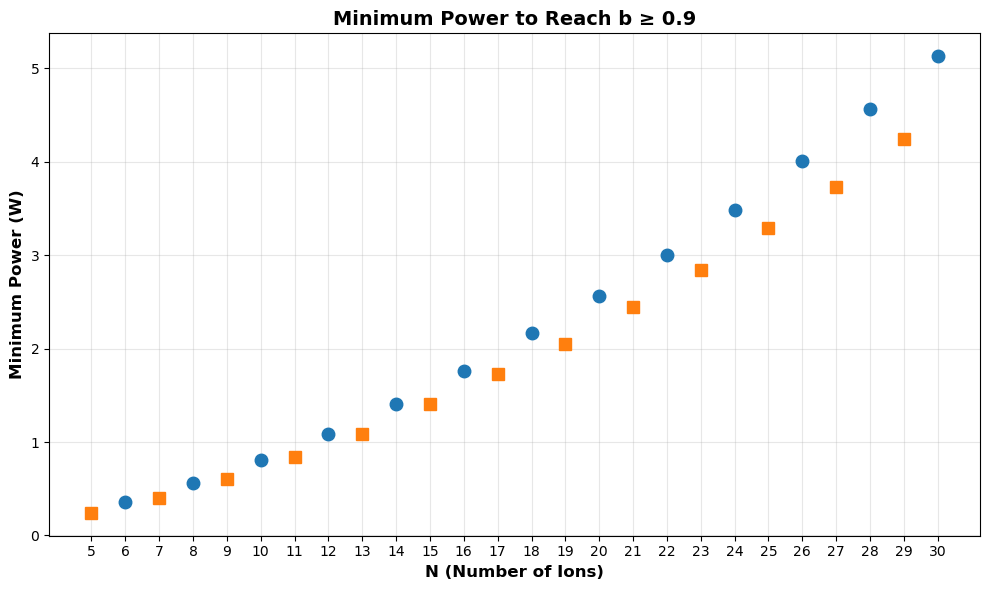

Even N values: [6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30]
Even N power values (W): [0.3617034068136272, 0.5620941883767535, 0.8025631262525049, 1.0831102204408816, 1.4037354709418837, 1.764438877755511, 2.1652204408817632, 2.566002004008016, 3.0068617234468937, 3.4877995991983965, 4.008815631262525, 4.569909819639279, 5.131004008016032]
Odd N values: [5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29]
Odd N power values (W): [0.2414689378757515, 0.40178156312625246, 0.6021723446893787, 0.8426412825651303, 1.0831102204408816, 1.4037354709418837, 1.7243607214428855, 2.0449859719438876, 2.44576753507014, 2.8465490981963923, 3.2874088176352703, 3.728268537074148, 4.249284569138276]

Frequency differences at P = 241.4689 mW (target: 241.4689 mW), N=5:
  Mode 0-1: 28.7282 kHz
  Mode 1-2: 1.4150 kHz
  Mode 2-3: 19.8146 kHz
  Mode 3-4: 2.9102 kHz

Frequency differences at P = 361.7034 mW (target: 361.7034 mW), N=6:
  Mode 0-1: 23.4280 kHz
  Mode 1-2: 5.5555 kHz
  Mode 2-3: 7.4185 kHz
  M

In [ ]:
def plot_coupling_vs_N_at_target_separate(N_values, target_coupling, omega_tweezer, linewidths, omega_res, m, mode_calc_r, f_rf_r, ueq_dict, w0):
    power_values_even = []
    N_achieved_even = []
    power_values_odd = []
    N_achieved_odd = []
    powers_for_each_N = np.linspace(0.001, 20, 500)

    for N in N_values:
        min_power_for_target = None
        for power in powers_for_each_N:
            results_df = tweezer_combos_full_radial_middle_only(
                omega_tweezer, linewidths, omega_res, m, mode_calc_r,
                N_list=[N], f_rf_r=f_rf_r, ueq_dict=ueq_dict, P_opt=power, w0=w0
            )
            extracted = extract_mode0_at_tweezed(results_df)
            if N % 2 == 0:
                value = extracted[0].get("quad_sum", None)
            else:
                b_value = extracted[0].get("values", np.array([None]))[0] if len(extracted[0].get("values", np.array([]))) > 0 else None
                value = abs(b_value) if b_value is not None else None
            if value is not None and value >= target_coupling:
                min_power_for_target = power
                break
        if min_power_for_target is not None:
            if N % 2 == 0:
                power_values_even.append(min_power_for_target)
                N_achieved_even.append(N)
            else:
                power_values_odd.append(min_power_for_target)
                N_achieved_odd.append(N)

    if len(N_achieved_even) > 0 or len(N_achieved_odd) > 0:
        plt.figure(figsize=(10, 6))
        if N_achieved_even:
            plt.plot(N_achieved_even, power_values_even, marker="o", markersize=9, color="#1f77b4", label="Even N", linestyle="None")
        if N_achieved_odd:
            plt.plot(N_achieved_odd, power_values_odd, marker="s", markersize=9, color="#ff7f0e", label="Odd N", linestyle="None")
        plt.xlabel("N (Number of Ions)", fontsize=12, fontweight="bold")
        plt.ylabel("Minimum Power (W)", fontsize=12, fontweight="bold")
        plt.title(f"Minimum Power to Reach b \u2265 {target_coupling}", fontsize=14, fontweight="bold")
        plt.xticks(sorted(N_achieved_even + N_achieved_odd))
        plt.grid(True, alpha=0.3)
        #plt.legend(fontsize=11)
        plt.tight_layout()
        plt.show()

    print(f"Even N values: {N_achieved_even}")
    print(f"Even N power values (W): {power_values_even}")
    print(f"Odd N values: {N_achieved_odd}")
    print(f"Odd N power values (W): {power_values_odd}")

    return {N: p for N, p in zip(N_achieved_even + N_achieved_odd, power_values_even + power_values_odd)}


import pandas as pd

N_values = np.arange(5, 31, 1)
target_coupling = 0.90

target_powers = plot_coupling_vs_N_at_target_separate(
    N_values,
    target_coupling,
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    f_rf_r=3e6,
    ueq_dict=ueq_dict,
    w0=1e-6,
)

# For each N at its target power, compute and print mode frequency differences
records = []
for N in sorted(target_powers.keys()):
    P_t = target_powers[N]

    result_df = tweezer_combos_full_radial_middle_only(
        omega_tweezer, linewidths, omega_res, m, mode_calc_r,
        N_list=[N], f_rf_r=3e6, ueq_dict=ueq_dict, P_opt=P_t, w0=1e-6,
    )

    mode_freqs = {}
    for mode_idx in range(N):
        col = f"Mode{mode_idx}_freq"
        if col in result_df.columns:
            val = result_df[col].values[0]
            mode_freqs[mode_idx] = val if not np.isnan(val) else None

    print(f"\nFrequency differences at P = {P_t*1e3:.4f} mW (target: {P_t*1e3:.4f} mW), N={N}:")
    for mode_idx in range(N - 1):
        f0 = mode_freqs.get(mode_idx)
        f1 = mode_freqs.get(mode_idx + 1)
        if f0 is not None and f1 is not None:
            diff_kHz = (f0 - f1) / 1e3
            print(f"  Mode {mode_idx}-{mode_idx+1}: {diff_kHz:.4f} kHz")
            records.append({
                "N": N,
                "target_P_W": P_t,
                "target_P_mW": P_t * 1e3,
                "mode_pair": f"{mode_idx}-{mode_idx+1}",
                "freq_diff_kHz": diff_kHz,
            })

df_mode_diffs = pd.DataFrame(records)
print("\nDataFrame:")
print(df_mode_diffs.to_string())


In [ ]:
df_mode_diffs

,N,target_P_W,target_P_mW,mode_pair,freq_diff_kHz
0,5,0.241469,241.468938,0-1,28.728155
1,5,0.241469,241.468938,1-2,1.414966
2,5,0.241469,241.468938,2-3,19.814556
3,5,0.241469,241.468938,3-4,2.910182
4,6,0.361703,361.703407,0-1,23.428003
5,6,0.361703,361.703407,1-2,5.555491
6,6,0.361703,361.703407,2-3,7.418466
7,6,0.361703,361.703407,3-4,19.339134
8,6,0.361703,361.703407,4-5,3.439011
9,7,0.401782,401.781563,0-1,40.999500


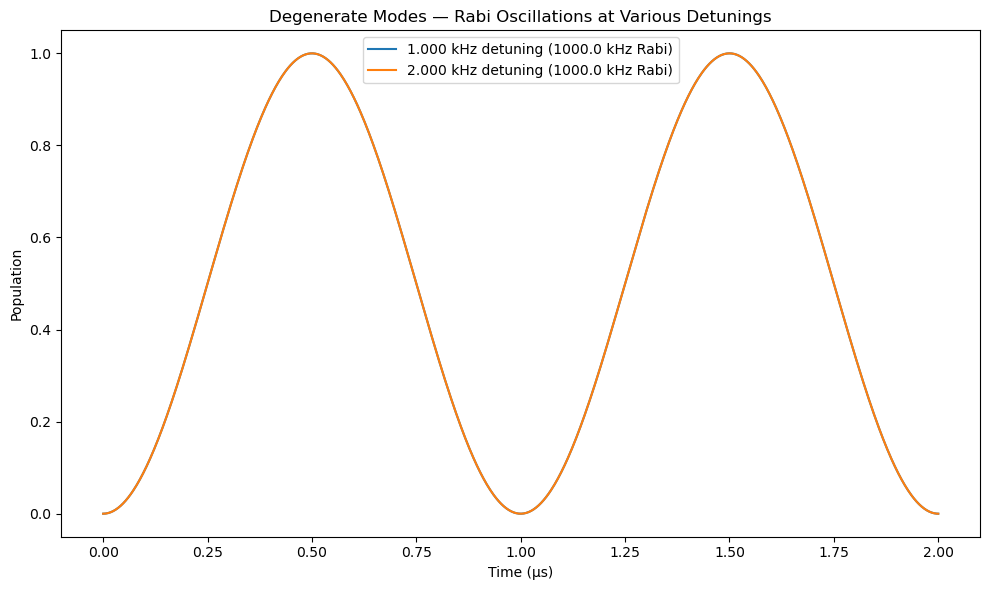


Time to first peak for each detuning:
  1.000 kHz detuning: t_peak = 0.5000 µs (peak P = 1.000)
  2.000 kHz detuning: t_peak = 0.5000 µs (peak P = 1.000)


In [ ]:
Omega_0 = 1e6 * 2 * pi  # 100 kHz in rad/s

detunings_kHz = [1.0, 2.0]
time = np.linspace(0, 2e-6, 1000)  # Time from 0 to 2 microseconds

plt.figure(figsize=(10, 6))
for det_kHz in detunings_kHz:
    delta = det_kHz * 2 * pi*1e3  # convert kHz to rad/s
    Rabi_freq = np.sqrt(Omega_0**2 + delta**2)
    coeff = (Omega_0 / Rabi_freq)**2
    P = coeff * np.sin(Rabi_freq * time / 2)**2
    plt.plot(time * 1e6, P, label=f"{det_kHz:.3f} kHz detuning ({Rabi_freq/(2*pi*1e3):.1f} kHz Rabi)")

plt.xlabel("Time (\u00b5s)")
plt.ylabel("Population")
#plt.ylim(0.9, 1.005)
#plt.xlim(0,10)
plt.title("Degenerate Modes \u2014 Rabi Oscillations at Various Detunings")
plt.legend()
plt.tight_layout()
plt.show()

print("\nTime to first peak for each detuning:")
for det_kHz in detunings_kHz:
    delta = det_kHz * 2 * pi * 1e3
    Rabi_freq = np.sqrt(Omega_0**2 + delta**2)
    coeff = (Omega_0 / Rabi_freq)**2
    t_peak = np.pi / Rabi_freq
    print(f"  {det_kHz:.3f} kHz detuning: t_peak = {t_peak*1e6:.4f} \u00b5s (peak P = {coeff:.3f})")


Saved: /Users/ritika/SQRL_Rithi_python/BladeRunner/Tweezers/sideband_spectrum.pdf
Saved: /Users/ritika/SQRL_Rithi_python/BladeRunner/Tweezers/sideband_spectrum.png


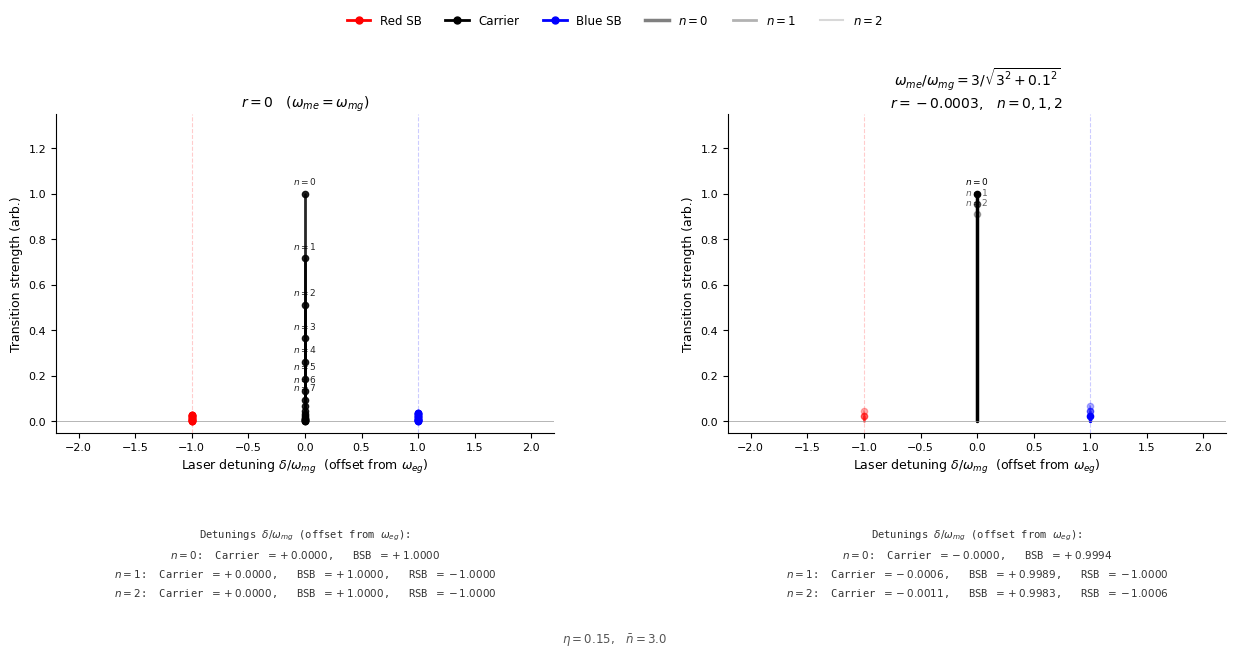

In [ ]:
"""
Sideband spectrum with correct Franck-Condon factors.

Physics:
  - Ground state mechanical frequency: omega_mg
  - Excited state mechanical frequency: omega_me
  - Squeezing parameter: r = 1/2 * ln(omega_me / omega_mg)
    r is fully determined by the frequency ratio; it is NOT a free parameter.
  - Squeezing operator S(r) = exp(r/2 * (a^2 - a_dag^2)) relates the two bases
  - In the Lamb-Dicke limit, the FC amplitude for |g,n> -> |e,n'> is:
        f_{n'n} = <n'|S(r)|n>  +  i*eta*sqrt(n)  * <n'|S(r)|n-1>
                                +  i*eta*sqrt(n+1) * <n'|S(r)|n+1>
  - Transition strengths:
        Carrier (n'=n):   |F_n^0|^2  = |<n|S(r)|n> * (1 - eta^2/2*(2n+1))|^2
        Blue SB (n'=n+1): eta^2 * |sqrt(n+1)*<n+1|S(r)|n+1> + sqrt(n)*<n+1|S(r)|n-1>|^2
        Red SB  (n'=n-1): eta^2 * |sqrt(n)  *<n-1|S(r)|n-1> + sqrt(n+1)*<n-1|S(r)|n+1>|^2
  - Resonance frequencies (offset from omega_eg, in units of omega_mg):
        Carrier: delta =  n * Domega,          Domega = omega_me/omega_mg - 1
        Blue SB: delta = +omega_me/omega_mg + n * Domega
        Red SB:  delta = -omega_me/omega_mg + n * Domega   (n >= 1)
  - Thermal weights: p(n) = nbar^n / (nbar+1)^(n+1)
"""

import os
import numpy as np
from scipy.linalg import expm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── colour palette ────────────────────────────────────────────────────────
COL_CARRIER = 'black'
COL_RED     = 'red'
COL_BLUE    = 'blue'

# Physical ratio for panel 2
OMEGA_RATIO_2 = 3.0 / np.sqrt(3.0**2 + 0.1**2)   # omega_me / omega_mg


def r_from_ratio(omega_ratio):
    """r = 1/2 * ln(omega_me / omega_mg).  Accepts any positive ratio."""
    return 0.5 * np.log(omega_ratio)


def squeezing_matrix(r, dim):
    G = np.zeros((dim, dim))
    for k in range(dim):
        if k >= 2:
            G[k-2, k] += 0.5 * r * np.sqrt(k * (k-1))
        if k + 2 < dim:
            G[k+2, k] -= 0.5 * r * np.sqrt((k+1) * (k+2))
    return expm(G)


def thermal(n, nbar):
    if nbar < 1e-9:
        return 1.0 if n == 0 else 0.0
    return (nbar / (nbar + 1))**n / (nbar + 1)


def compute_lines(eta, nbar, omega_ratio, nmax=25, n_filter=None):
    """
    omega_ratio : omega_me / omega_mg
    n_filter    : if set, return only lines from initial state n=n_filter
                  with unit weight (ignores thermal distribution).
    """
    r      = r_from_ratio(omega_ratio)
    Domega = omega_ratio - 1.0
    dim    = nmax + 6
    S      = squeezing_matrix(r, dim)
    wme    = omega_ratio

    n_range = [n_filter] if n_filter is not None else range(nmax)

    lines = []
    for n in n_range:
        pn = 1.0 if n_filter is not None else thermal(n, nbar)
        if pn < 1e-8:
            continue

        fc0 = S[n, n] * (1.0 - 0.5 * eta**2 * (2*n + 1))
        lines.append(dict(freq=n * Domega, strength=pn * fc0**2,
                          kind='carrier', n=n))

        Sn1n1  = S[n+1, n+1] if n+1 < dim else 0.0
        Sn1nm1 = S[n+1, n-1] if (n >= 1 and n+1 < dim) else 0.0
        Fp = np.sqrt(n+1) * Sn1n1 + np.sqrt(n) * Sn1nm1
        lines.append(dict(freq=wme + n * Domega, strength=pn * eta**2 * Fp**2,
                          kind='blue', n=n))

        if n >= 1:
            Snm1nm1 = S[n-1, n-1]
            Snm1n1  = S[n-1, n+1] if n+1 < dim else 0.0
            Fm = np.sqrt(n) * Snm1nm1 + np.sqrt(n+1) * Snm1n1
            lines.append(dict(freq=-(wme - n * Domega), strength=pn * eta**2 * Fm**2,
                              kind='red', n=n))

    return lines


KIND_COL = {'carrier': COL_CARRIER, 'red': COL_RED, 'blue': COL_BLUE}
N_ALPHA  = {0: 1.0, 1: 0.60, 2: 0.30}
N_LW     = {0: 2.5, 1: 2.0,  2: 1.5}


def plot_spectrum(ax, lines, title='', freq_range=None,
                  show_n_labels=True, n_label_thresh=0.05,
                  normalise=True, multi_n=False):
    if not lines:
        return

    max_s = max(l['strength'] for l in lines) or 1.0

    for line in lines:
        s   = line['strength'] / max_s if normalise else line['strength']
        f   = line['freq']
        n   = line['n']
        col = KIND_COL[line['kind']]
        alpha = N_ALPHA.get(n, 0.25) if multi_n else 0.85
        lw    = N_LW.get(n, 1.5)    if multi_n else 2.0

        ax.plot([f, f], [0, s], color=col, lw=lw, alpha=alpha,
                solid_capstyle='round')
        ax.plot(f, s, 'o', color=col, ms=4.5, alpha=alpha, zorder=5)

        if show_n_labels and s > n_label_thresh:
            ax.text(f, s + 0.03, f'$n={n}$',
                    ha='center', va='bottom', fontsize=6.5,
                    color=col, alpha=max(alpha, 0.6))

    ax.axhline(0, color='#999', lw=0.5)
    for xref, c in [(1.0, COL_BLUE), (-1.0, COL_RED)]:
        ax.axvline(xref, color=c, lw=0.8, ls='--', alpha=0.20)

    if freq_range:
        ax.set_xlim(*freq_range)
    ax.set_ylim(-0.05, 1.35)
    ax.set_ylabel('Transition strength (arb.)', fontsize=9)
    ax.set_xlabel(r'Laser detuning $\delta/\omega_{mg}$  (offset from $\omega_{eg}$)',
                  fontsize=9)
    ax.set_title(title, fontsize=10, pad=5)
    ax.tick_params(labelsize=8)
    ax.spines[['top', 'right']].set_visible(False)


def _detuning_label(ax, omega_ratio, n_list):
    """Add a per-n detuning table (in units of omega_mg) below an axis."""
    Domega = omega_ratio - 1.0
    wme    = omega_ratio
    rows   = [r'Detunings $\delta/\omega_{mg}$ (offset from $\omega_{eg}$):']
    for n in n_list:
        carrier = n * Domega
        bsb     = wme + n * Domega
        if n >= 1:
            rsb = -(wme - n * Domega)
            rows.append(
                f'$n={n}$:  Carrier $= {carrier:+.4f}$,   '
                f'BSB $= {bsb:+.4f}$,   RSB $= {rsb:+.4f}$'
            )
        else:
            rows.append(
                f'$n={n}$:  Carrier $= {carrier:+.4f}$,   '
                f'BSB $= {bsb:+.4f}$'
            )
    text = '\n'.join(rows)
    ax.text(0.5, -0.30, text, transform=ax.transAxes,
            ha='center', va='top', fontsize=7.5,
            family='monospace', color='#333',
            linespacing=1.6)


def make_figure():
    fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))
    fig.patch.set_facecolor('white')
    fig.subplots_adjust(wspace=0.35, left=0.07, right=0.97, top=0.82, bottom=0.33)

    eta        = 0.15
    nbar       = 3.0
    freq_range = (-2.2, 2.2)

    # Panel 1: r = 0  (omega_ratio = 1.0, no frequency shift)
    lines1 = compute_lines(eta=eta, nbar=nbar, omega_ratio=1.0, nmax=20)
    plot_spectrum(axes[0], lines1,
                  title=r'$r = 0$   ($\omega_{me} = \omega_{mg}$)',
                  freq_range=freq_range,
                  show_n_labels=True, n_label_thresh=0.07,
                  normalise=True, multi_n=False)
    _detuning_label(axes[0], omega_ratio=1.0, n_list=[0, 1, 2])

    # Panel 2: omega_me/omega_mg = 3/sqrt(3^2+0.1^2),  n = 0, 1, 2
    ratio = OMEGA_RATIO_2
    r_val = r_from_ratio(ratio)

    all_lines = []
    for n in [0, 1, 2]:
        ls = compute_lines(eta=eta, nbar=nbar, omega_ratio=ratio,
                           nmax=20, n_filter=n)
        all_lines.extend(ls)

    gmax = max(l['strength'] for l in all_lines) if all_lines else 1.0
    for l in all_lines:
        l['strength'] /= gmax

    plot_spectrum(axes[1], all_lines,
                  title=(r'$\omega_{me}/\omega_{mg} = 3/\sqrt{3^2+0.1^2}$'
                         + '\n'
                         + rf'$r = {r_val:.4f}$,   $n = 0, 1, 2$'),
                  freq_range=freq_range,
                  show_n_labels=True, n_label_thresh=0.07,
                  normalise=False, multi_n=True)
    _detuning_label(axes[1], omega_ratio=ratio, n_list=[0, 1, 2])

    # Shared legend
    from matplotlib.lines import Line2D
    elems = [
        Line2D([0],[0], color=COL_RED,     lw=2, marker='o', ms=5, label='Red SB'),
        Line2D([0],[0], color=COL_CARRIER, lw=2, marker='o', ms=5, label='Carrier'),
        Line2D([0],[0], color=COL_BLUE,    lw=2, marker='o', ms=5, label='Blue SB'),
        Line2D([0],[0], color='gray', lw=N_LW[0], alpha=N_ALPHA[0], label=r'$n=0$'),
        Line2D([0],[0], color='gray', lw=N_LW[1], alpha=N_ALPHA[1], label=r'$n=1$'),
        Line2D([0],[0], color='gray', lw=N_LW[2], alpha=N_ALPHA[2], label=r'$n=2$'),
    ]
    fig.legend(handles=elems, loc='upper center', ncol=6,
               fontsize=8.5, frameon=False, bbox_to_anchor=(0.5, 0.99))

    fig.text(0.5, 0.005, rf'$\eta = {eta}$,   $\bar{{n}} = {nbar}$',
             ha='center', fontsize=8.5, color='#555')

    return fig


fig = make_figure()

out_pdf = 'sideband_spectrum.pdf'
out_png = 'sideband_spectrum.png'
fig.savefig(out_pdf, dpi=200, bbox_inches='tight', facecolor='white')
print(f'Saved: {os.path.abspath(out_pdf)}')
fig.savefig(out_png, dpi=200, bbox_inches='tight', facecolor='white')
print(f'Saved: {os.path.abspath(out_png)}')
plt.show()


In [ ]:
# Gaussian beam propagation
lam = 532e-9
w0 = 1e-6
z_R = np.pi * w0**2 / lam

z_span = 12   # half-span in units of z_R
r_span = 2    # half-span in units of w0

z_vals = np.linspace(-z_span * z_R, z_span * z_R, 800)
r_vals = np.linspace(-r_span * w0, r_span * w0, 400)
Z, R = np.meshgrid(z_vals, r_vals)
W = w0 * np.sqrt(1 + (Z / z_R)**2)
I = np.exp(-2 * R**2 / W**2)

fig, ax = plt.subplots(figsize=(14, 3))
ax.imshow(
    I,
    extent=[z_vals[0]*1e6, z_vals[-1]*1e6, r_vals[0]*1e6, r_vals[-1]*1e6],
    origin='lower', aspect='auto', cmap='Greens', vmin=0, vmax=1
)
ax.axis('off')
plt.subplots_adjust(0, 0, 1, 1)
plt.show()

In [ ]:
from PIL import Image

# Apply Greens colormap to get RGBA array
cmap = plt.cm.Greens
rgba = cmap(I)  # shape (H, W, 4), values in [0,1]

# Zero alpha outside the 1/e^2 radius (where I < exp(-2))
rgba[I < np.exp(-2), 3] = 0

img = Image.fromarray((rgba * 255).astype(np.uint8), 'RGBA')
img.save('gaussian_beam_transparent.png')
print('Saved gaussian_beam_transparent.png')

Saved gaussian_beam_transparent.png


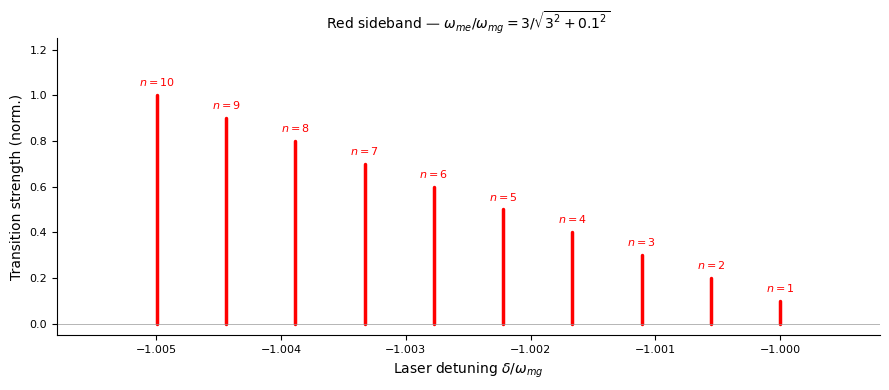

In [ ]:
# RSB-only zoom: right panel (omega_me/omega_mg = 3/sqrt(3^2+0.1^2))
ratio  = OMEGA_RATIO_2
eta    = 0.15
nbar   = 3.0

rsb_lines = []
for n in range(1, 11):
    ls = compute_lines(eta=eta, nbar=nbar, omega_ratio=ratio, nmax=20, n_filter=n)
    rsb_lines.extend(l for l in ls if l['kind'] == 'red')

max_s = max(l['strength'] for l in rsb_lines)
for l in rsb_lines:
    l['strength'] /= max_s

freqs = [l['freq'] for l in rsb_lines]
pad   = 0.0008
xlim  = (min(freqs) - pad, max(freqs) + pad)

fig, ax = plt.subplots(figsize=(9, 4))
for line in rsb_lines:
    ax.plot([line['freq'], line['freq']], [0, line['strength']],
            color=COL_RED, lw=2.5, solid_capstyle='round')
    ax.text(line['freq'], line['strength'] + 0.03, f"$n={line['n']}$",
            ha='center', va='bottom', fontsize=8, color=COL_RED)

ax.axhline(0, color='#999', lw=0.5)
ax.set_xlim(*xlim)
ax.set_ylim(-0.05, 1.25)
ax.set_xlabel(r'Laser detuning $\delta/\omega_{mg}$', fontsize=10)
ax.set_ylabel('Transition strength (norm.)', fontsize=10)
ax.set_title(r'Red sideband — $\omega_{me}/\omega_{mg} = 3/\sqrt{3^2+0.1^2}$', fontsize=10)
ax.tick_params(labelsize=8)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('rsb_zoom.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()


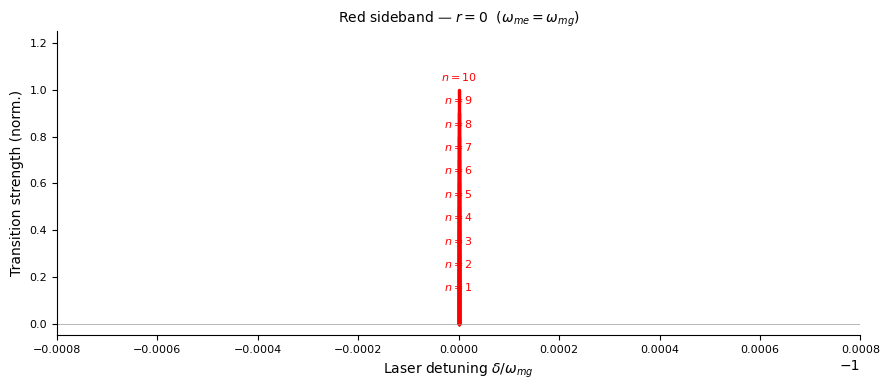

In [ ]:
# RSB-only zoom: r=0 case (omega_me = omega_mg)
ratio  = 1.0
eta    = 0.15
nbar   = 3.0

rsb_lines = []
for n in range(1, 11):
    ls = compute_lines(eta=eta, nbar=nbar, omega_ratio=ratio, nmax=20, n_filter=n)
    rsb_lines.extend(l for l in ls if l['kind'] == 'red')

max_s = max(l['strength'] for l in rsb_lines)
for l in rsb_lines:
    l['strength'] /= max_s

freqs = [l['freq'] for l in rsb_lines]
pad   = 0.0008
xlim  = (min(freqs) - pad, max(freqs) + pad)

fig, ax = plt.subplots(figsize=(9, 4))
for line in rsb_lines:
    ax.plot([line['freq'], line['freq']], [0, line['strength']],
            color=COL_RED, lw=2.5, solid_capstyle='round')
    ax.text(line['freq'], line['strength'] + 0.03, f"$n={line['n']}$",
            ha='center', va='bottom', fontsize=8, color=COL_RED)

ax.axhline(0, color='#999', lw=0.5)
ax.set_xlim(*xlim)
ax.set_ylim(-0.05, 1.25)
ax.set_xlabel(r'Laser detuning $\delta/\omega_{mg}$', fontsize=10)
ax.set_ylabel('Transition strength (norm.)', fontsize=10)
ax.set_title(r'Red sideband — $r=0$  ($\omega_{me} = \omega_{mg}$)', fontsize=10)
ax.tick_params(labelsize=8)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('rsb_zoom_r0.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()


In [ ]:
# Print RSB transition strengths for both cases
eta  = 0.15
nbar = 3.0

for label, ratio in [('r=0  (omega_me=omega_mg)', 1.0),
                      ('omega_me/omega_mg = 3/sqrt(3^2+0.1^2)', OMEGA_RATIO_2)]:
    print(f'--- {label} ---')
    print(f'  {"n":>3}   {"RSB strength (unnorm)":>22}   {"RSB strength (norm)":>20}')
    lines = []
    for n in range(1, 11):
        ls = compute_lines(eta=eta, nbar=nbar, omega_ratio=ratio, nmax=20, n_filter=n)
        rsb = [l for l in ls if l['kind'] == 'red']
        if rsb:
            lines.append((n, rsb[0]['strength']))
    max_s = max(s for _, s in lines)
    for n, s in lines:
        print(f'  {n:>3}   {s:>22.6e}   {s/max_s:>20.6f}')
    print()


--- r=0  (omega_me=omega_mg) ---
    n    RSB strength (unnorm)    RSB strength (norm)
    1             2.250000e-02               0.100000
    2             4.500000e-02               0.200000
    3             6.750000e-02               0.300000
    4             9.000000e-02               0.400000
    5             1.125000e-01               0.500000
    6             1.350000e-01               0.600000
    7             1.575000e-01               0.700000
    8             1.800000e-01               0.800000
    9             2.025000e-01               0.900000
   10             2.250000e-01               1.000000

--- omega_me/omega_mg = 3/sqrt(3^2+0.1^2) ---
    n    RSB strength (unnorm)    RSB strength (norm)
    1             2.248751e-02               0.100251
    2             4.496252e-02               0.200446
    3             6.742504e-02               0.300585
    4             8.987507e-02               0.400669
    5             1.123126e-01               0.500697
  